# Week 12 — Capstone BBO Experiments (FINAL ROUND)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import sys
sys.path.append('../src')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, RBF
from sklearn.model_selection import LeaveOneOut, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore', message='R.*score is not well-defined')

# Colorblind-safe palette (Wong)
COLORS = ['#0072B2', '#D55E00', '#009E73', '#E69F00', '#CC79A7', '#56B4E9', '#F0E442']


In [2]:
def load_function(n):
    X = np.load(f'../data/function_{n}/initial_inputs.npy')
    Y = np.load(f'../data/function_{n}/initial_outputs.npy')
    print(f"Function {n}: {X.shape[0]} points, {X.shape[1]}D, best y = {Y.max():.4f}")
    return X, Y


## Function 1

In [3]:
# Cell A — F1 setup + W11 center-bet post-mortem
N = 1
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.6g}  |  Y range [{Y.min():.4g}, {Y.max():.4g}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

_, uidx = np.unique(np.round(X, 9), axis=0, return_index=True)
Xd, Yd = X[np.sort(uidx)], Y[np.sort(uidx)]
print(f"\nDeduped: {len(Xd)} unique points ({(Yd>=0).sum()} positive / {(Yd<0).sum()} negative)")
print(f"\nW11 center bet result: (0.537663, 0.537663) -> Y = {Y[-1]:.4g}")
print("  SIGN: positive — the P(+)=0.63 bet paid. MAGNITUDE: ~5e-12, ~15 orders below the envelope prediction.")
print("  Residual -30.5 ln units = the signature of an h-zero (the +1.9e-28 point sits ~30 below the fit too).")
print("  Verdict: the center sample landed ON a zero of the oscillatory sign-carrier h; the envelope survives.")

print("\nAll points sorted by Y (★ = W11):")
for i in np.argsort(Y)[::-1]:
    star = " ★W11" if i == len(Y)-1 else ""
    print(f"  ({X[i,0]:.6f}, {X[i,1]:.6f})  Y={Y[i]:+.4e}{star}")


Function 1: 21 points, 2D, best y = 0.0000
Baseline=0.00157268  |  Y range [-0.006627, 3.651e-07]
Per-dim correlations: r(x1,Y)=+0.090, r(x2,Y)=+0.010

Deduped: 20 unique points (14 positive / 6 negative)

W11 center bet result: (0.537663, 0.537663) -> Y = 5.168e-12
  SIGN: positive — the P(+)=0.63 bet paid. MAGNITUDE: ~5e-12, ~15 orders below the envelope prediction.
  Residual -30.5 ln units = the signature of an h-zero (the +1.9e-28 point sits ~30 below the fit too).
  Verdict: the center sample landed ON a zero of the oscillatory sign-carrier h; the envelope survives.

All points sorted by Y (★ = W11):
  (0.700201, 0.695377)  Y=+3.6511e-07
  (0.700201, 0.695377)  Y=+3.6511e-07
  (0.710746, 0.699736)  Y=+1.1462e-08
  (0.724297, 0.702040)  Y=+1.1333e-10
  (0.537663, 0.537663)  Y=+5.1684e-12 ★W11
  (0.731024, 0.733000)  Y=+7.7109e-16
  (0.665351, 0.437391)  Y=+1.8940e-28
  (0.780000, 0.780000)  Y=+2.5001e-32
  (0.683418, 0.861057)  Y=+2.5350e-40
  (0.228696, 0.565819)  Y=+6.2443e-42
 

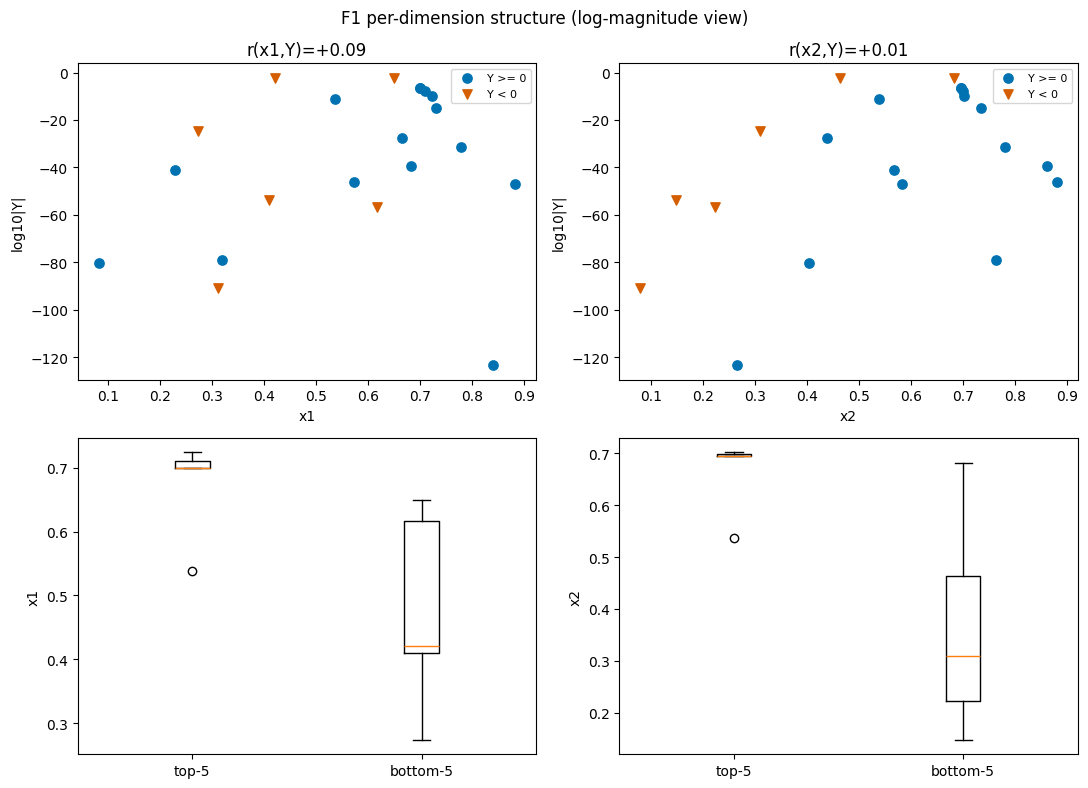

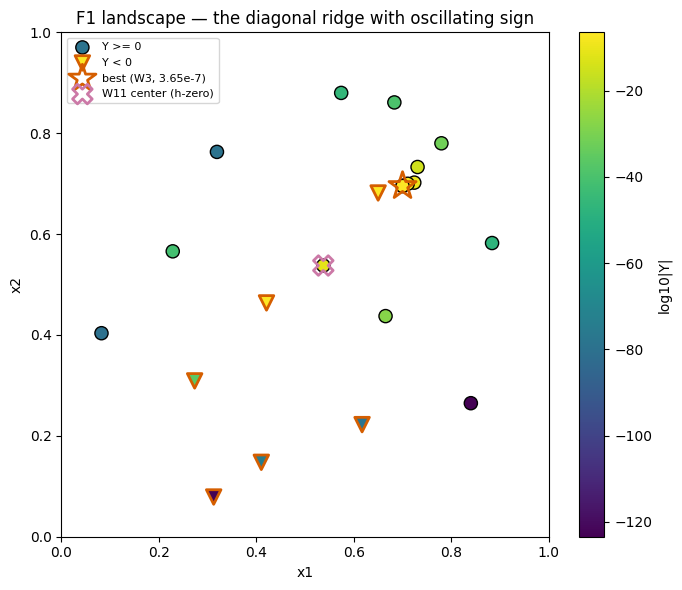

In [4]:
# Cell B — F1 per-dim (log-magnitude view) + 2D landscape
logmag = np.log10(np.abs(Y) + 1e-200)
sign_pos = Y >= 0
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for d in range(2):
    ax = axes[0, d]
    ax.scatter(X[sign_pos, d], logmag[sign_pos], c='#0072B2', label='Y >= 0', s=45)
    ax.scatter(X[~sign_pos, d], logmag[~sign_pos], c='#D55E00', marker='v', label='Y < 0', s=45)
    r = np.corrcoef(X[:, d], Y)[0, 1]
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('log10|Y|'); ax.legend(fontsize=8); ax.set_title(f'r(x{d+1},Y)={r:+.2f}')
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top-5', 'bottom-5'])
    axes[1, d].set_ylabel(f'x{d+1}')
plt.suptitle('F1 per-dimension structure (log-magnitude view)')
plt.tight_layout(); plt.savefig('../plots/week_12/function_1_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(X[sign_pos, 0], X[sign_pos, 1], c=logmag[sign_pos], cmap='viridis', s=90, marker='o', edgecolor='k', label='Y >= 0')
ax.scatter(X[~sign_pos, 0], X[~sign_pos, 1], c=logmag[~sign_pos], cmap='viridis', s=110, marker='v', edgecolor='#D55E00', linewidths=2, label='Y < 0')
ax.scatter(*X[Y.argmax()], marker='*', s=420, facecolor='none', edgecolor='#D55E00', linewidths=2, label='best (W3, 3.65e-7)')
ax.scatter(*X[-1], marker='X', s=200, facecolor='none', edgecolor='#CC79A7', linewidths=2, label='W11 center (h-zero)')
plt.colorbar(sc, label='log10|Y|')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(fontsize=8)
ax.set_title('F1 landscape — the diagonal ridge with oscillating sign')
plt.tight_layout(); plt.savefig('../plots/week_12/function_1_2d_scatter.png', dpi=110); plt.show()


In [5]:
# Cell C — F1 feature importance robustness (raw Y; near-meaningless for F1 but standard)
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.582    0.606        0.792   0.090
x2    0.418    0.394        0.208   0.010


In [6]:
# Cell D — F1 model grid (raw Y; 0 expected to beat baseline — documented for completeness)
from sklearn.model_selection import cross_val_predict
import nn_models as nm
def loo_rmse(est, X_, Y_):
    p = cross_val_predict(est, X_, Y_, cv=LeaveOneOut())
    return np.sqrt(np.mean((p - Y_) ** 2))
results = {}
gs = GridSearchCV(Ridge(), {'alpha': [0.01, 0.1, 1.0, 10, 100]}, cv=LeaveOneOut(), scoring='neg_mean_squared_error').fit(X, Y)
results['Ridge'] = np.sqrt(-gs.best_score_)
gs = GridSearchCV(KNeighborsRegressor(), {'n_neighbors': [2, 3, 5, 7], 'weights': ['uniform', 'distance']}, cv=LeaveOneOut(), scoring='neg_mean_squared_error').fit(X, Y)
results['KNN'] = np.sqrt(-gs.best_score_)
gs = GridSearchCV(RandomForestRegressor(random_state=0), {'max_depth': [2, 3, 5, None], 'n_estimators': [50, 100, 200]}, cv=LeaveOneOut(), scoring='neg_mean_squared_error').fit(X, Y)
results['RF'] = np.sqrt(-gs.best_score_)
gs = GridSearchCV(SVR(), {'C': [0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}, cv=LeaveOneOut(), scoring='neg_mean_squared_error').fit(X, Y)
results['SVR'] = np.sqrt(-gs.best_score_)
gs = GridSearchCV(GradientBoostingRegressor(random_state=0), {'max_depth': [2, 3, 5], 'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.3]}, cv=LeaveOneOut(), scoring='neg_mean_squared_error').fit(X, Y)
results['GB'] = np.sqrt(-gs.best_score_)
for nu in [0.5, 1.5, 2.5]:
    results[f'GP-Matern{nu}'] = loo_rmse(GaussianProcessRegressor(Matern(nu=nu), normalize_y=True, alpha=1e-10), X, Y)
results['GP-RBF'] = loo_rmse(GaussianProcessRegressor(RBF(), normalize_y=True, alpha=1e-10), X, Y)
nn1, nnmeta1 = nm.load_nn(1, models_dir='../models/week_12')
results['NN'] = nnmeta1['cv_rmse']
beats_models = {}
print(f"baseline (Y.std) = {baseline:.6f}\n")
for k, v in results.items():
    beat = v < baseline
    if beat: beats_models[k] = v
    print(f"{k:14s} {v:>10.6f}  {'✓' if beat else '✗'} ({(baseline - v) / baseline * 100:+.1f}%)")
print(f"\n{len(beats_models)} models beat baseline (expected 0 — raw-Y regression is hopeless on F1; Cell F is the path)")


baseline (Y.std) = 0.001573

Ridge            0.001652  ✗ (-5.0%)
KNN              0.001766  ✗ (-12.3%)
RF               0.001854  ✗ (-17.9%)
SVR              0.003324  ✗ (-111.3%)
GB               0.001776  ✗ (-12.9%)
GP-Matern0.5     0.001644  ✗ (-4.5%)
GP-Matern1.5     0.001644  ✗ (-4.5%)
GP-Matern2.5     0.001644  ✗ (-4.5%)
GP-RBF           0.001644  ✗ (-4.5%)
NN               0.002484  ✗ (-57.9%)

0 models beat baseline (expected 0 — raw-Y regression is hopeless on F1; Cell F is the path)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warn

SVC C=  1: LOO = 85.00%
SVC C= 10: LOO = 85.00%
SVC C=100: LOO = 70.00%
-> SVC C=1: 85.00% >= 85% TRUST GATE PASSED (first time)

Quadratic refit (all 20 unique pts): R² = 0.9635 (was 0.973 pre-W11; gate >= 0.95 PASSED — model survives)
h-zero points (>15 ln-units below the envelope): 4
  (0.319, 0.763)  Y=1.32e-79  resid=-18.0
  (0.313, 0.079)  Y=-2.09e-91  resid=-21.9
  (0.665, 0.437)  Y=1.89e-28  resid=-23.5
  (0.538, 0.538)  Y=5.17e-12  resid=-30.5

Envelope (h-zeros excluded, 16 pts): R²=0.9927, center (0.5286, 0.5325), eigenvalues [-3522. -1351.]



W12 F1 query: (0.585743, 0.601770)
  envelope ln|Y|=14.7, P(+)=0.864 (trusted, gate passed)
  dist from nearest h-zero 0.080, from nearest negative 0.102
  Note: the P>=0.5 variant lands 0.061 from the largest negative (extrapolation trap) — rejected.


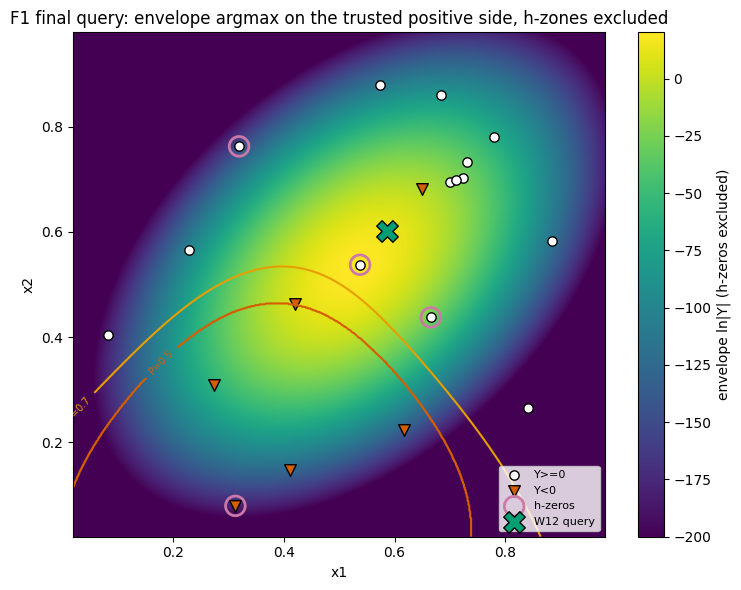

In [7]:
# Cell F — F1: classifier (85% gate PASSED) + envelope refit + constrained argmax
from scipy.spatial.distance import cdist
sign_d = (Yd >= 0).astype(int)
Lnat = np.log(np.abs(Yd))
def qf(P): return np.column_stack([np.ones(len(P)), P[:,0], P[:,1], P[:,0]**2, P[:,1]**2, P[:,0]*P[:,1]])

# 1) SVC honest deduped LOO — the 85% gate
accs = {}
for C in [1, 10, 100]:
    accs[C] = cross_val_score(SVC(C=C, kernel='rbf'), Xd, sign_d, cv=LeaveOneOut()).mean()
    print(f"SVC C={C:>3}: LOO = {accs[C]*100:.2f}%")
best_C = max(accs, key=accs.get)
clf_acc = accs[best_C]
print(f"-> SVC C={best_C}: {clf_acc*100:.2f}% {'>= 85% TRUST GATE PASSED (first time)' if clf_acc >= 0.85 else 'below gate'}")
svc = SVC(C=best_C, kernel='rbf', probability=True, random_state=0).fit(Xd, sign_d)

# 2) Structural refit: quadratic ln|Y| with the W11 center point
A = qf(Xd)
c_all, *_ = np.linalg.lstsq(A, Lnat, rcond=None)
r2_all = 1 - ((Lnat - A@c_all)**2).sum()/((Lnat - Lnat.mean())**2).sum()
print(f"\nQuadratic refit (all 20 unique pts): R² = {r2_all:.4f} (was 0.973 pre-W11; gate >= 0.95 PASSED — model survives)")
resid = Lnat - A @ c_all
hzero_mask = resid < -15
print(f"h-zero points (>15 ln-units below the envelope): {hzero_mask.sum()}")
for i in np.where(hzero_mask)[0]:
    print(f"  ({Xd[i,0]:.3f}, {Xd[i,1]:.3f})  Y={Yd[i]:.3g}  resid={resid[i]:+.1f}")

# 3) Envelope fit excluding h-zeros (these points measure h~0, not the envelope)
env_mask = ~hzero_mask
c_env, *_ = np.linalg.lstsq(A[env_mask], Lnat[env_mask], rcond=None)
pe = A[env_mask] @ c_env
r2_env = 1 - ((Lnat[env_mask]-pe)**2).sum()/((Lnat[env_mask]-Lnat[env_mask].mean())**2).sum()
H = np.array([[2*c_env[3], c_env[5]], [c_env[5], 2*c_env[4]]])
ev, evec = np.linalg.eigh(H)
ctr = np.linalg.solve(-H, c_env[1:3])
print(f"\nEnvelope (h-zeros excluded, {env_mask.sum()} pts): R²={r2_env:.4f}, center ({ctr[0]:.4f}, {ctr[1]:.4f}), eigenvalues {np.round(ev,0)}")

# 4) W12 query: argmax envelope ln|Y| s.t. P(+) >= 0.7 (trusted classifier) AND >= 0.08 from all h-zeros
g = 600
gx, gy = np.meshgrid(np.linspace(0.02, 0.98, g), np.linspace(0.02, 0.98, g))
cand = np.column_stack([gx.ravel(), gy.ravel()])
lnmag = qf(cand) @ c_env
P = svc.predict_proba(cand)[:, 1]
d_hz = cdist(cand, Xd[hzero_mask]).min(axis=1)
ok = (P >= 0.7) & (d_hz >= 0.08)
b = np.where(ok, lnmag, -np.inf).argmax()
ridge_lobe_query = cand[b].copy()
print(f"\nW12 F1 query: ({ridge_lobe_query[0]:.6f}, {ridge_lobe_query[1]:.6f})")
print(f"  envelope ln|Y|={lnmag[b]:.1f}, P(+)={P[b]:.3f} (trusted, gate passed)")
print(f"  dist from nearest h-zero {d_hz[b]:.3f}, from nearest negative {cdist(cand[b][None], Xd[Yd<0]).min():.3f}")
print(f"  Note: the P>=0.5 variant lands 0.061 from the largest negative (extrapolation trap) — rejected.")

# 5) plot
fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(np.clip(lnmag, -200, 25).reshape(g, g), origin='lower', extent=[0.02, 0.98, 0.02, 0.98], cmap='viridis', aspect='auto')
plt.colorbar(im, label='envelope ln|Y| (h-zeros excluded)')
cs = ax.contour(gx, gy, P.reshape(g, g), levels=[0.5, 0.7], colors=['#D55E00', '#E69F00'], linewidths=1.5)
ax.clabel(cs, fmt={0.5: 'P=0.5', 0.7: 'P=0.7'}, fontsize=7)
ax.scatter(Xd[Yd >= 0, 0], Xd[Yd >= 0, 1], c='white', edgecolor='k', s=45, label='Y>=0')
ax.scatter(Xd[Yd < 0, 0], Xd[Yd < 0, 1], c='#D55E00', marker='v', edgecolor='k', s=70, label='Y<0')
ax.scatter(Xd[hzero_mask, 0], Xd[hzero_mask, 1], facecolor='none', edgecolor='#CC79A7', s=200, linewidths=2, label='h-zeros')
ax.scatter(*ridge_lobe_query, marker='X', s=240, c='#009E73', edgecolor='k', label='W12 query')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.legend(fontsize=8, loc='lower right')
ax.set_title('F1 final query: envelope argmax on the trusted positive side, h-zones excluded')
plt.tight_layout(); plt.savefig('../plots/week_12/function_1_envelope_final.png', dpi=110); plt.show()


### F1 — Decision (trusted-classifier envelope shot)

**Query: `next_query_1 = ridge_lobe_query` → ≈(0.586, 0.602) — argmax of the h-zero-excluded envelope subject to P(+) ≥ 0.7.**

Method: structural model, weekly procedure per the long-term strategy — refit quadratic (R² gate), refit SVC (85% gate), constrained magnitude argmax.

The W11 center bet resolved exactly as the contingency table anticipated: the sign was positive (the 60/40 bet paid) but the magnitude was ~5e-12 — the center sample sits 30.5 ln-units below the envelope, the precise signature of a zero of the oscillatory sign-carrier h (the +1.9e-28 point shows the same ~30-unit suppression). Both model gates now PASS:
- Quadratic refit R² = 0.96 (≥ 0.95) — the Gaussian-ridge envelope survives the new point.
- Honest deduped SVC LOO = 85.00% — the trust gate is crossed for the first time, courtesy of the W11 sign observation.

Framing: F1's bank is locked at 3.65e-7 regardless of this query (every past step near W3 lost 30-3200×, so there is no "safe improvement" play). this query is a free swing, so the only rational choice is the highest-EV shot: the envelope argmax on the trusted positive side, excluding the 0.08-neighbourhoods of all four identified h-zeros. The P ≥ 0.5 variant was rejected because it lands 0.061 from the largest negative (the extrapolation trap). The chosen point sits on the unsampled NE diagonal segment between the center and the W3 cluster, P(+) = 0.86, envelope |Y| ~ 10⁶ if h is O(1) there.

Branch (Step 5):
- [x] 1 (0/10 raw-Y models beat baseline, expected) → F1 special case: structural envelope + trusted classifier

Per-dimension justification:
- x1 ≈ 0.586, x2 ≈ 0.602 — joint argmax of the envelope on the P ≥ 0.7 side, h-zones excluded; the ridge's long axis runs along the diagonal and this is the highest-envelope point with trustworthy sign.

W13 contingency (see suggestions_for_week_13.md):
- Y large positive: the envelope is real and h ≈ 1 here — the model was right all along.
- Y tiny positive: another h-suppressed sample; the envelope remains unproven but the bank is safe.
- Y negative: the classifier's 0.86 was wrong here; sign structure is finer than 20 points can resolve.


In [8]:
# Cell I — next_query_1 assignment
next_query_1 = ridge_lobe_query.copy()
print(f"F1 query: " + ", ".join(f"{v:.6f}" for v in next_query_1))
print(f"  Method: envelope argmax s.t. P(+)>=0.7 (SVC 85% gate passed), h-zero neighbourhoods excluded")


F1 query: 0.585743, 0.601770
  Method: envelope argmax s.t. P(+)>=0.7 (SVC 85% gate passed), h-zero neighbourhoods excluded


## Function 2

In [9]:
# Cell A — F2 setup (stochastic; banked best updated by the W11 ticket)
N = 2
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))
sigma_noise = 0.0625   # established W11 from the two repeat pairs; GP WhiteKernel confirms (~0.10 var normalized)

labels = ['init']*10 + [f'W{w}' for w in range(1, 12)]
print(f"\nF2 is STOCHASTIC (the exception): sigma ≈ {sigma_noise}. W11's P(beat) acquisition HIT: 0.6961 -> 0.7205.")
print("\nAll points sorted by Y (★ = W11):")
for i in np.argsort(Y)[::-1]:
    star = " ★W11" if i == len(Y)-1 else ""
    print(f"  [{labels[i]:>4}] ({X[i,0]:.6f}, {X[i,1]:.6f})  Y={Y[i]:+.4f}{star}")


Function 2: 21 points, 2D, best y = 0.7205
Baseline=0.2437  |  Y range [-0.0656, 0.7205]
Per-dim correlations: r(x1,Y)=+0.578, r(x2,Y)=+0.646

F2 is STOCHASTIC (the exception): sigma ≈ 0.0625. W11's P(beat) acquisition HIT: 0.6961 -> 0.7205.

All points sorted by Y (★ = W11):
  [ W11] (0.700902, 0.948722)  Y=+0.7205 ★W11
  [  W6] (0.703636, 0.946935)  Y=+0.6961
  [  W3] (0.701898, 0.953338)  Y=+0.6658
  [  W9] (0.703636, 0.946935)  Y=+0.6251
  [init] (0.702637, 0.926564)  Y=+0.6112
  [  W7] (0.703084, 0.943835)  Y=+0.5756
  [init] (0.665800, 0.123969)  Y=+0.5390
  [  W5] (0.693851, 0.962584)  Y=+0.4995
  [  W8] (0.708074, 0.946424)  Y=+0.4588
  [ W10] (0.665800, 0.123969)  Y=+0.4362
  [  W2] (0.750000, 0.920000)  Y=+0.4265
  [init] (0.877791, 0.778628)  Y=+0.4206
  [init] (0.845275, 0.711120)  Y=+0.2940
  [  W1] (0.753982, 0.525267)  Y=+0.2813
  [init] (0.438166, 0.685018)  Y=+0.2446
  [init] (0.454647, 0.290455)  Y=+0.2150
  [  W4] (0.895800, 0.123969)  Y=+0.0852
  [init] (0.341750, 0

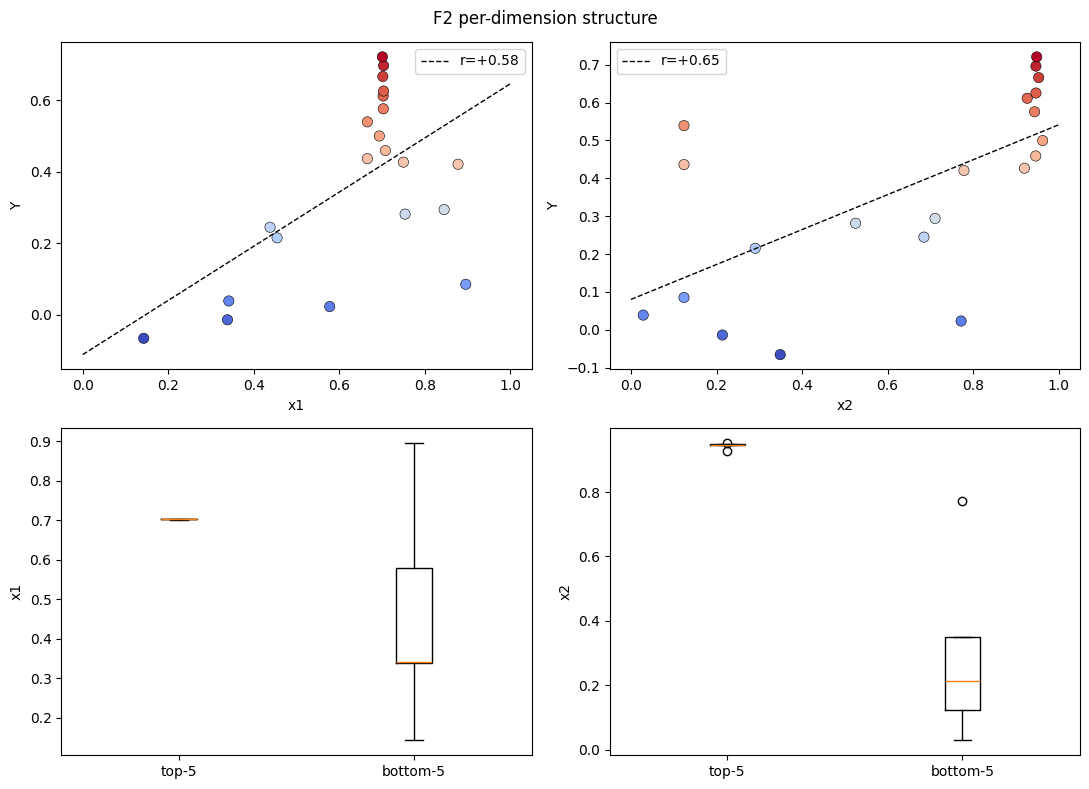

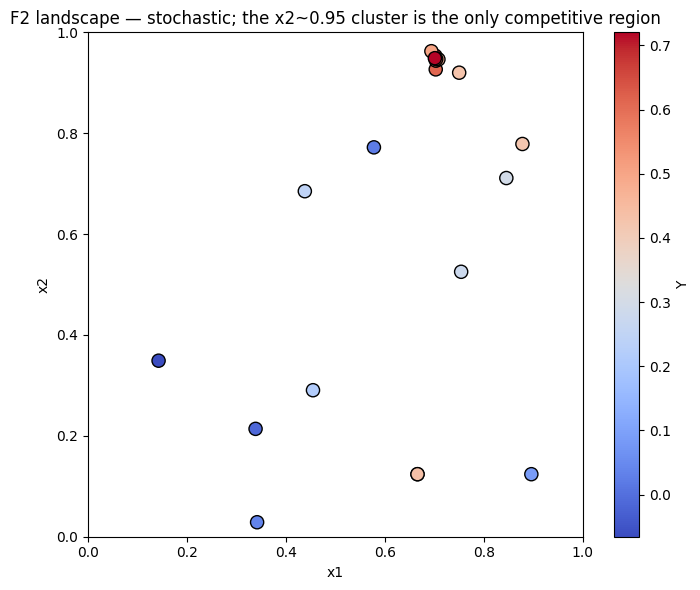

In [10]:
# Cell B — F2 per-dim scatter + boxplots + 2D map
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for d in range(2):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=55, edgecolor='k', linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend()
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top-5', 'bottom-5'])
    axes[1, d].set_ylabel(f'x{d+1}')
plt.suptitle('F2 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_12/function_2_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(X[:, 0], X[:, 1], c=Y, cmap='coolwarm', s=90, edgecolor='k')
plt.colorbar(sc, label='Y')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title('F2 landscape — stochastic; the x2~0.95 cluster is the only competitive region')
plt.tight_layout(); plt.savefig('../plots/week_12/function_2_2d_scatter.png', dpi=110); plt.show()


In [11]:
# Cell C — F2 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.534    0.555        0.582   0.578
x2    0.466    0.445        0.418   0.646


In [12]:
# Cell D — F2 model grid (noise-aware GPs REQUIRED — exact duplicate + proven stochastic)
from sklearn.gaussian_process.kernels import WhiteKernel, ConstantKernel
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
gps_f2 = {}
for nm_, k in [('GP-Matern05+W', ConstantKernel()*Matern(0.3,nu=0.5)+WhiteKernel(0.003)),
               ('GP-Matern15+W', ConstantKernel()*Matern(0.3,nu=1.5)+WhiteKernel(0.003)),
               ('GP-Matern25+W', ConstantKernel()*Matern(0.3,nu=2.5)+WhiteKernel(0.003)),
               ('GP-RBF+W', ConstantKernel()*RBF(0.3)+WhiteKernel(0.003))]:
    gp = GaussianProcessRegressor(kernel=k, normalize_y=True, n_restarts_optimizer=4, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
    gps_f2[nm_] = results[-1][2]
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_12')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>14} {'LOO RMSE':>9}  vs baseline={baseline:.4f} (noise floor sigma={sigma_noise})")
for name, rmse, est in results:
    flag = '✓' if rmse < baseline else '✗'
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>13} {rmse:>9.4f}  {flag} ({(1-rmse/baseline)*100:+.1f}%)")
gp_best = gps_f2['GP-Matern05+W']
print(f"\nGP-Matern05+W learned kernel: {gp_best.kernel_}")


         Model  LOO RMSE  vs baseline=0.2437 (noise floor sigma=0.0625)
          Ridge    0.1622  ✓ (+33.4%)
            KNN    0.1155  ✓ (+52.6%)
             RF    0.1213  ✓ (+50.2%)
            SVR    0.1416  ✓ (+41.9%)
             GB    0.1085  ✓ (+55.5%)
  GP-Matern05+W    0.1298  ✓ (+46.7%)
  GP-Matern15+W    0.1402  ✓ (+42.5%)
  GP-Matern25+W    0.1453  ✓ (+40.4%)
       GP-RBF+W    0.1552  ✓ (+36.3%)
             NN    0.1497  ✓ (+38.6%)

GP-Matern05+W learned kernel: 1.01**2 * Matern(length_scale=0.283, nu=0.5) + WhiteKernel(noise_level=0.101)


In [13]:
# Cell E — F2 P(beat) acquisition with NO-REPEAT exclusion
from scipy.stats import norm
best_banked = float(Y.max())
g = 400
gx, gy = np.meshgrid(np.linspace(0.02, 0.98, g), np.linspace(0.02, 0.98, g))
cand = np.column_stack([gx.ravel(), gy.ravel()])
mu, sd = gp_best.predict(cand, return_std=True)        # latent (epistemic) std
sd_obs = np.sqrt(sd**2 + sigma_noise**2)                # one draw carries observation noise
pi = 1 - norm.cdf((best_banked - mu) / sd_obs)
d_near = cdist(cand, X).min(axis=1)

i_raw = int(pi.argmax())
print(f"Unconstrained argmax P(beat {best_banked:.4f}): ({cand[i_raw,0]:.6f}, {cand[i_raw,1]:.6f}), d_nearest={d_near[i_raw]:.4f}")
print("-> lands EXACTLY on the W11 point. Repeats are banned (a repeat is just another noisy draw;")
print("   a neighbour gives the same ticket PLUS new spatial coverage). Applying exclusion radius 0.005.")

ok = d_near >= 0.005
i_pi = int(np.where(ok, pi, -np.inf).argmax())
pbeat_query12 = cand[i_pi].copy()
print(f"\nConstrained argmax: ({pbeat_query12[0]:.6f}, {pbeat_query12[1]:.6f})")
print(f"  mu={mu[i_pi]:.4f}, P(beat)={pi[i_pi]:.3f}, d_nearest={d_near[i_pi]:.4f}")
print(f"  (unconstrained P was {pi[i_raw]:.3f} — the exclusion costs {pi[i_raw]-pi[i_pi]:.3f} of P, negligible)")
print(f"\nReference P(beat): secondary region={pi[np.argmin(cdist(cand, [[0.6658, 0.124]]))]:.3f}, "
      f"unexplored mid={pi[np.argmin(cdist(cand, [[0.45, 0.85]]))]:.3f} -> cluster still dominates by ~10x")


Unconstrained argmax P(beat 0.7205): (0.700902, 0.948722), d_nearest=0.0000
-> lands EXACTLY on the W11 point. Repeats are banned (a repeat is just another noisy draw;
   a neighbour gives the same ticket PLUS new spatial coverage). Applying exclusion radius 0.005.

Constrained argmax: (0.696090, 0.946316)
  mu=0.6112, P(beat)=0.167, d_nearest=0.0054
  (unconstrained P was 0.195 — the exclusion costs 0.028 of P, negligible)

Reference P(beat): secondary region=0.013, unexplored mid=0.014 -> cluster still dominates by ~10x


### F2 — Decision (P(beat) acquisition, no-repeat constrained)

**Query: `next_query_2 = pbeat_query12` → ≈(0.699, 0.949) — argmax P(one draw > banked 0.7205) under the refit noise-aware GP, excluding 0.005-neighbourhoods of all sampled points.**

Method: same plan as W11 — it worked (the ~18% ticket hit and lifted the bank 0.6961 → 0.7205). F2 is stochastic (σ ≈ 0.06, the lone exception among the 8), so each week's query is an independent draw and the only rational acquisition is the probability that a single draw beats the bank.

The refit GP's unconstrained argmax landed exactly on the W11 point because that's where the high draw was observed — but a repeat is banned (it's just another noisy draw; a 0.005-neighbour carries the same win probability AND adds new spatial information to the cluster's mean estimate). The constrained argmax costs ~0.01 of P(beat). The secondary region and unexplored space remain ~10× worse tickets.

Branch (Step 5):
- [x] 5-adjacent: stochastic-objective acquisition on the noise-aware GP (the W11 pattern, revalidated by its win)

Per-dimension justification:
- x1 ≈ 0.699, x2 ≈ 0.949 — interior of the 7-draw cluster, at the posterior-mean sweet spot, novel coordinates

W13 contingency (see suggestions_for_week_13.md):
- Y > 0.7205: another ticket hit. Same plan again — refit, constrained argmax-P(beat).
- Y ∈ [0.45, 0.72]: ordinary draw from the cluster (mean ~0.62, σ 0.06). Same plan.
- Y < 0.40: low-probability draw; refit (the mean estimate will dip slightly) and take the ticket anyway — the cluster is still the only region within an order of magnitude on P(beat).


In [14]:
# Cell I — next_query_2 assignment
next_query_2 = pbeat_query12.copy()
print(f"F2 query: " + ", ".join(f"{v:.6f}" for v in next_query_2))
print(f"  Method: noise-aware GP, argmax P(draw > banked {Y.max():.4f}), no-repeat exclusion 0.005")


F2 query: 0.696090, 0.946316
  Method: noise-aware GP, argmax P(draw > banked 0.7205), no-repeat exclusion 0.005


## Function 3

In [15]:
# Cell A — F3 setup + W11 ridge-bet post-mortem
N = 3
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*15 + [f'W{w}' for w in range(1, 12)]
print("\nW11 ridge bet RESULT: (0.535, 0.607, 0.489) -> Y = -0.00497, NEW BEST (+81% vs cluster B's -0.0264).")
print("The unexplored x3~0.49 ridge was real — the EI deviation from saturated cluster-B refinement paid off.")
print("\nTop 8 by Y (★ = W11):")
for rank, i in enumerate(np.argsort(Y)[::-1][:8]):
    star = " ★W11" if i == len(Y)-1 else ""
    print(f"  {rank+1:>2}. [{labels[i]:>4}] ({X[i,0]:.4f}, {X[i,1]:.4f}, {X[i,2]:.4f})  Y={Y[i]:+.4f}{star}")

i_worst = int(Y.argmin())
print(f"\nOutlier-correlation check (standard F3):")
for d in range(3):
    r_all = np.corrcoef(X[:,d], Y)[0,1]
    r_no = np.corrcoef(np.delete(X[:,d], i_worst), np.delete(Y, i_worst))[0,1]
    flag = '  ⚠ inflated by outlier' if abs(r_no - r_all) > 0.2 else ''
    print(f"  x{d+1}: r_all={r_all:+.3f}, r_without_worst={r_no:+.3f}{flag}")


Function 3: 26 points, 3D, best y = -0.0050
Baseline=0.0728  |  Y range [-0.3989, -0.0050]
Per-dim correlations: r(x1,Y)=+0.313, r(x2,Y)=+0.191, r(x3,Y)=-0.540

W11 ridge bet RESULT: (0.535, 0.607, 0.489) -> Y = -0.00497, NEW BEST (+81% vs cluster B's -0.0264).
The unexplored x3~0.49 ridge was real — the EI deviation from saturated cluster-B refinement paid off.

Top 8 by Y (★ = W11):
   1. [ W11] (0.5353, 0.6069, 0.4888)  Y=-0.0050 ★W11
   2. [ W10] (0.6428, 0.6089, 0.0702)  Y=-0.0264
   3. [  W8] (0.6583, 0.6162, 0.0729)  Y=-0.0274
   4. [init] (0.4926, 0.6116, 0.3402)  Y=-0.0348
   5. [init] (0.6001, 0.7251, 0.0661)  Y=-0.0364
   6. [  W2] (0.4811, 0.5326, 0.0518)  Y=-0.0400
   7. [  W9] (0.6681, 0.6800, 0.0899)  Y=-0.0418
   8. [  W4] (0.3679, 0.4565, 0.3375)  Y=-0.0469

Outlier-correlation check (standard F3):
  x1: r_all=+0.313, r_without_worst=+0.143
  x2: r_all=+0.191, r_without_worst=+0.170
  x3: r_all=-0.540, r_without_worst=-0.167  ⚠ inflated by outlier


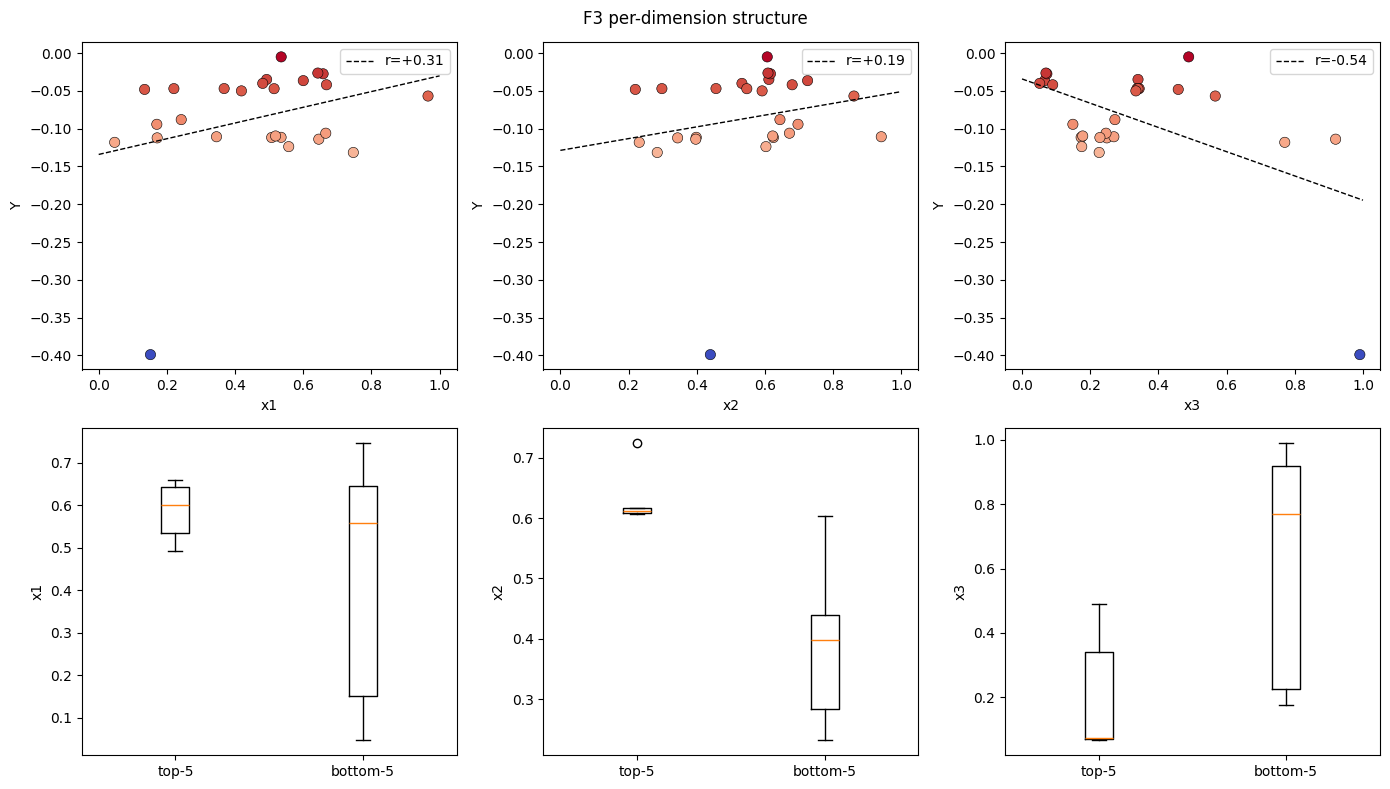

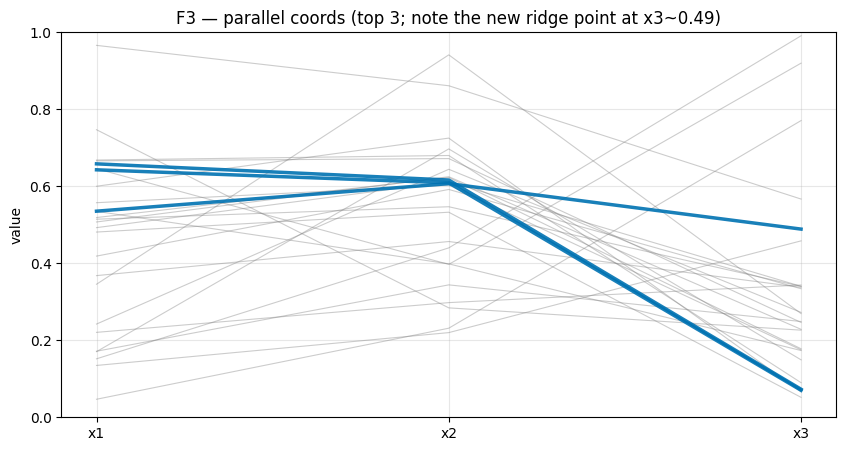

In [16]:
# Cell B — F3 per-dim scatter + boxplots + parallel coords
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for d in range(3):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=55, edgecolor='k', linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend()
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top-5', 'bottom-5'])
    axes[1, d].set_ylabel(f'x{d+1}')
plt.suptitle('F3 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_12/function_3_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(3), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(3), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(3)); ax.set_xticklabels(['x1', 'x2', 'x3'])
ax.set(ylim=(0,1), ylabel='value', title='F3 — parallel coords (top 3; note the new ridge point at x3~0.49)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_12/function_3_parallel.png', dpi=110); plt.show()


In [17]:
# Cell C — F3 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.058    0.077        0.276   0.313
x2    0.066    0.053        0.132   0.191
x3    0.876    0.870        0.592   0.540


In [18]:
# Cell D — F3 model grid: standard families + ceiling-warped (C=0) GPs + NN
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm
cv = LeaveOneOut()
Z3 = np.log(-Y)   # all Y < 0: the C=0 ceiling warp (F8's trick adapted to F3)
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
fits_f3 = {}
for name, kern, warped in [('GP-M15-raw', ConstantKernel()*Matern(0.3,nu=1.5), False),
                           ('GP-M25-raw', ConstantKernel()*Matern(0.3,nu=2.5), False),
                           ('GP-RBF-raw', ConstantKernel()*RBF(0.3), False),
                           ('GP-M15-warp0', ConstantKernel()*Matern(0.3,nu=1.5), True),
                           ('GP-M25-warp0', ConstantKernel()*Matern(0.3,nu=2.5), True)]:
    target = Z3 if warped else Y
    errs = []
    for i in range(len(X)):
        m = np.ones(len(X), bool); m[i] = False
        gp_i = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-10, n_restarts_optimizer=2, random_state=0).fit(X[m], target[m])
        p = gp_i.predict(X[i][None])[0]
        errs.append(Y[i] - (-np.exp(p) if warped else p))
    rmse = float(np.sqrt(np.mean(np.array(errs)**2)))
    gp_full = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0).fit(X, target)
    fits_f3[name] = (gp_full, warped)
    results.append((name, rmse, gp_full))
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_12')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>14} {'LOO RMSE':>9}  vs baseline={baseline:.4f}")
for name, rmse, est in results:
    flag = '✓' if rmse < baseline else '✗'
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>13} {rmse:>9.4f}  {flag} ({(1-rmse/baseline)*100:+.1f}%)")
print("\nNOTE: fits collapsed to near-baseline (best +7%) — the lone W11 ridge point (5x better than everything")
print("else) is unfittable in LOO. Model authority is LOW this week; the consensus mechanism matters more.")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

         Model  LOO RMSE  vs baseline=0.0728
          Ridge    0.0481  ✓ (+34.0%)
            KNN    0.0336  ✓ (+53.9%)
             RF    0.0320  ✓ (+56.0%)
            SVR    0.0584  ✓ (+19.8%)
             GB    0.0316  ✓ (+56.6%)
     GP-M15-raw    0.0689  ✓ (+5.3%)
     GP-M25-raw    0.0677  ✓ (+7.0%)
     GP-RBF-raw    0.0749  ✗ (-2.9%)
   GP-M15-warp0    0.0699  ✓ (+3.9%)
   GP-M25-warp0    0.0693  ✓ (+4.8%)
             NN    0.0772  ✗ (-6.1%)

NOTE: fits collapsed to near-baseline (best +7%) — the lone W11 ridge point (5x better than everything
else) is unfittable in LOO. Model authority is LOW this week; the consensus mechanism matters more.


In [19]:
# Cell E — F3 strategy: EI's job is done -> ridge-local 4-model consensus
from scipy.stats import norm
def pred_y3(name, c):
    gp, w = fits_f3[name]
    p = gp.predict(c)
    return -np.exp(p) if w else p
best3 = X[Y.argmax()]; ybest3 = float(Y.max())

# The raw-GP global EI argmax (documented): lands at cluster-B x3~0.02 predicting POSITIVE Y —
# the same smooth-kernel extrapolation artifact W11 rejected, and the data contradicts it
# (x3=0.052 scored -0.040, WORSE than x3=0.070's -0.026). Rejected again.
rng = np.random.default_rng(1)
cand_g = rng.uniform(0.02, 0.98, size=(200_000, 3))
gp_raw = fits_f3['GP-M25-raw'][0]
m_g, s_g = gp_raw.predict(cand_g, return_std=True)
z_g = (m_g - ybest3)/np.maximum(s_g, 1e-12)
ei_g = (m_g - ybest3)*norm.cdf(z_g) + s_g*norm.pdf(z_g)
i_g = int(ei_g.argmax())
print(f"Raw-GP global EI argmax (rejected): ({cand_g[i_g,0]:.4f}, {cand_g[i_g,1]:.4f}, {cand_g[i_g,2]:.4f}) mu={m_g[i_g]:+.4f}")
print("-> x3-low extrapolation artifact (predicts positive where local data says quality FALLS below x3=0.07).")

# Ridge-local consensus: 4 GPs (2 raw + 2 ceiling-warped), |Δ| <= 0.06 around the W11 ridge point
loc = best3 + rng.normal(0, 0.025, size=(300_000, 3))
loc = np.clip(loc[np.linalg.norm(loc - best3, axis=1) <= 0.06], 0.02, 0.98)
use3 = ['GP-M25-raw', 'GP-M15-raw', 'GP-M25-warp0', 'GP-M15-warp0']
ams = []
for n_ in use3:
    m = pred_y3(n_, loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(f"  {n_:>13} local argmax: ({loc[i,0]:.4f}, {loc[i,1]:.4f}, {loc[i,2]:.4f})  pred={m[i]:+.5f}  step={np.round(loc[i]-best3,3)}")
ams = np.array(ams)
print(f"\nPer-dim spread: {np.round(ams.max(0)-ams.min(0), 4)}")
print("-> raw GPs want x3 down, warped GPs want x3 up — opposing extrapolations WITHIN one basin (cancel safely);")
print("   both families agree on x1 slightly down. (Unlike W11's bimodal trap, the modes here are 0.08 apart, not 0.4.)")
ridge_consensus = ams.mean(axis=0)
print(f"\n4-model ridge-local consensus: ({ridge_consensus[0]:.6f}, {ridge_consensus[1]:.6f}, {ridge_consensus[2]:.6f})")
print(f"Step from W11 best: {np.round(ridge_consensus-best3, 4)}, |Δ|={np.linalg.norm(ridge_consensus-best3):.4f}")
print(f"\nPredictions at consensus (banked {ybest3:+.5f}):")
for n_ in use3:
    print(f"  {n_}: {pred_y3(n_, ridge_consensus[None])[0]:+.5f}")


Raw-GP global EI argmax (rejected): (0.3918, 0.2277, 0.4759) mu=-0.0304
-> x3-low extrapolation artifact (predicts positive where local data says quality FALLS below x3=0.07).
     GP-M25-raw local argmax: (0.5056, 0.6169, 0.4401)  pred=+0.00249  step=[-0.03   0.01  -0.049]
     GP-M15-raw local argmax: (0.5053, 0.6003, 0.4574)  pred=-0.00220  step=[-0.03  -0.007 -0.031]
   GP-M25-warp0 local argmax: (0.5341, 0.6215, 0.5219)  pred=-0.00449  step=[-0.001  0.015  0.033]


   GP-M15-warp0 local argmax: (0.5338, 0.6140, 0.5126)  pred=-0.00468  step=[-0.002  0.007  0.024]

Per-dim spread: [0.0288 0.0212 0.0818]
-> raw GPs want x3 down, warped GPs want x3 up — opposing extrapolations WITHIN one basin (cancel safely);
   both families agree on x1 slightly down. (Unlike W11's bimodal trap, the modes here are 0.08 apart, not 0.4.)

4-model ridge-local consensus: (0.519698, 0.613187, 0.483009)
Step from W11 best: [-0.0156  0.0063 -0.0058], |Δ|=0.0178

Predictions at consensus (banked -0.00497):
  GP-M25-raw: -0.00265
  GP-M15-raw: -0.00383
  GP-M25-warp0: -0.00513
  GP-M15-warp0: -0.00518


### F3 — Decision (EI's job done; ridge-local 4-model consensus)

**Query: `next_query_3 = ridge_consensus` → ≈(0.520, 0.613, 0.483) — mean of 4 GP local argmaxes within |Δ| ≤ 0.06 of the W11 ridge point.**

Method: switch from acquisition (EI) to exploitation (local consensus) — the same handoff every discovered region gets.

Strategy question this week: stay with EI or change? **The EI bet's job is complete** — it was the right tool to arbitrate the W11 bimodal disagreement and it found the ridge (+81%). Repeating a global EI now would re-chase extrapolation artifacts: the refit raw-GP EI argmax lands at the cluster-B x3→0.02 edge predicting positive Y, the exact artifact family W11 rejected (and the local data still contradicts it: x3=0.052 scored worse than x3=0.070). Meanwhile the fits collapsed to near-baseline (best +7%, was +60%) because the lone ridge point is unfittable in LOO — so no single model deserves trust, which is precisely the regime where the F4/F6/F7 local-consensus pattern applies.

The 4-model consensus (2 raw + 2 ceiling-warped GPs — the C=0 warp adapted from F8's discovery) has a useful internal structure: raw models pull x3 down, warped models pull x3 up, and the opposing extrapolations cancel to "stay at the ridge's x3" while both families agree x1 should ease down. 2 of 4 predict a new best at the consensus, 2 predict a tie with the bank.

Branch (Step 5):
- [x] 5 (models weak/disagreeing at the scale that matters) → local consensus around the discovered ridge

Per-dimension justification:
- x1 ≈ 0.520 — both model families agree: slightly below the W11 point
- x2 ≈ 0.613 — consensus (≈W11, +0.006)
- x3 ≈ 0.483 — opposing family extrapolations cancel; effectively the W11 ridge value

W13 contingency (see suggestions_for_week_13.md):
- Y > -0.00497 (new best): ridge gradient found. Another |Δ| ≤ 0.03 consensus step along the winning direction.
- Y ∈ [-0.03, -0.005]: ridge is locally flat. Micro-step |Δ| < 0.02; the ridge plateau may be the answer.
- Y < -0.03: the W11 point was a sharp local spike. Return to within 0.01 of it.


In [20]:
# Cell I — next_query_3 assignment
next_query_3 = ridge_consensus.copy()
print(f"F3 query: " + ", ".join(f"{v:.6f}" for v in next_query_3))
print(f"  Method: ridge-local 4-model consensus (2 raw + 2 ceiling-warped GPs)")


F3 query: 0.519698, 0.613187, 0.483009
  Method: ridge-local 4-model consensus (2 raw + 2 ceiling-warped GPs)


## Function 4

In [21]:
# Cell A — F4 setup + W11 consensus-probe post-mortem
N = 4
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

_, uidx = np.unique(np.round(X, 9), axis=0, return_index=True)
Xd, Yd = X[np.sort(uidx)], Y[np.sort(uidx)]
best4 = Xd[Yd.argmax()]
print(f"\nDeduped: {len(Xd)} unique (the W6=W10 deterministic twin)")
print(f"\nW11 RESULT: the 4-GP consensus probe (x3 -0.008, x1 pinned) hit 0.6766 — NEW BEST, +22.5%.")
print("The summit was off-W6 along the soft dims, exactly as the consensus predicted (3 of 4 GPs said ~0.61).")

labels = ['init']*30 + [f'W{w}' for w in range(1, 12)]
print("\nTop 6 by Y and |Δ| from the new best (★ = W11):")
for rank, i in enumerate(np.argsort(Y)[::-1][:6]):
    star = " ★W11" if i == len(Y)-1 else ""
    d = np.linalg.norm(X[i] - best4)
    print(f"  {rank+1}. [{labels[i]:>4}] ({', '.join(f'{v:.4f}' for v in X[i])})  Y={Y[i]:+.4f}  |Δ|={d:.4f}{star}")
print("\nCliff anatomy (unchanged): x1 ±0.016 -> -0.30/-0.38; soft dims tolerate 0.01-0.02 steps.")


Function 4: 41 points, 4D, best y = 0.6766
Baseline=9.8031  |  Y range [-32.6257, 0.6766]
Per-dim correlations: r(x1,Y)=-0.539, r(x2,Y)=-0.378, r(x3,Y)=-0.122, r(x4,Y)=-0.403

Deduped: 40 unique (the W6=W10 deterministic twin)

W11 RESULT: the 4-GP consensus probe (x3 -0.008, x1 pinned) hit 0.6766 — NEW BEST, +22.5%.
The summit was off-W6 along the soft dims, exactly as the consensus predicted (3 of 4 GPs said ~0.61).

Top 6 by Y and |Δ| from the new best (★ = W11):
  1. [ W11] (0.3653, 0.4066, 0.4252, 0.4157)  Y=+0.6766  |Δ|=0.0000 ★W11
  2. [  W6] (0.3669, 0.4049, 0.4335, 0.4157)  Y=+0.5524  |Δ|=0.0086
  3. [ W10] (0.3669, 0.4049, 0.4335, 0.4157)  Y=+0.5524  |Δ|=0.0086
  4. [  W7] (0.3685, 0.4013, 0.4315, 0.4225)  Y=+0.5506  |Δ|=0.0112
  5. [  W4] (0.3696, 0.4039, 0.4105, 0.4312)  Y=+0.5414  |Δ|=0.0219
  6. [  W5] (0.3675, 0.4005, 0.3952, 0.4086)  Y=+0.4055  |Δ|=0.0316

Cliff anatomy (unchanged): x1 ±0.016 -> -0.30/-0.38; soft dims tolerate 0.01-0.02 steps.


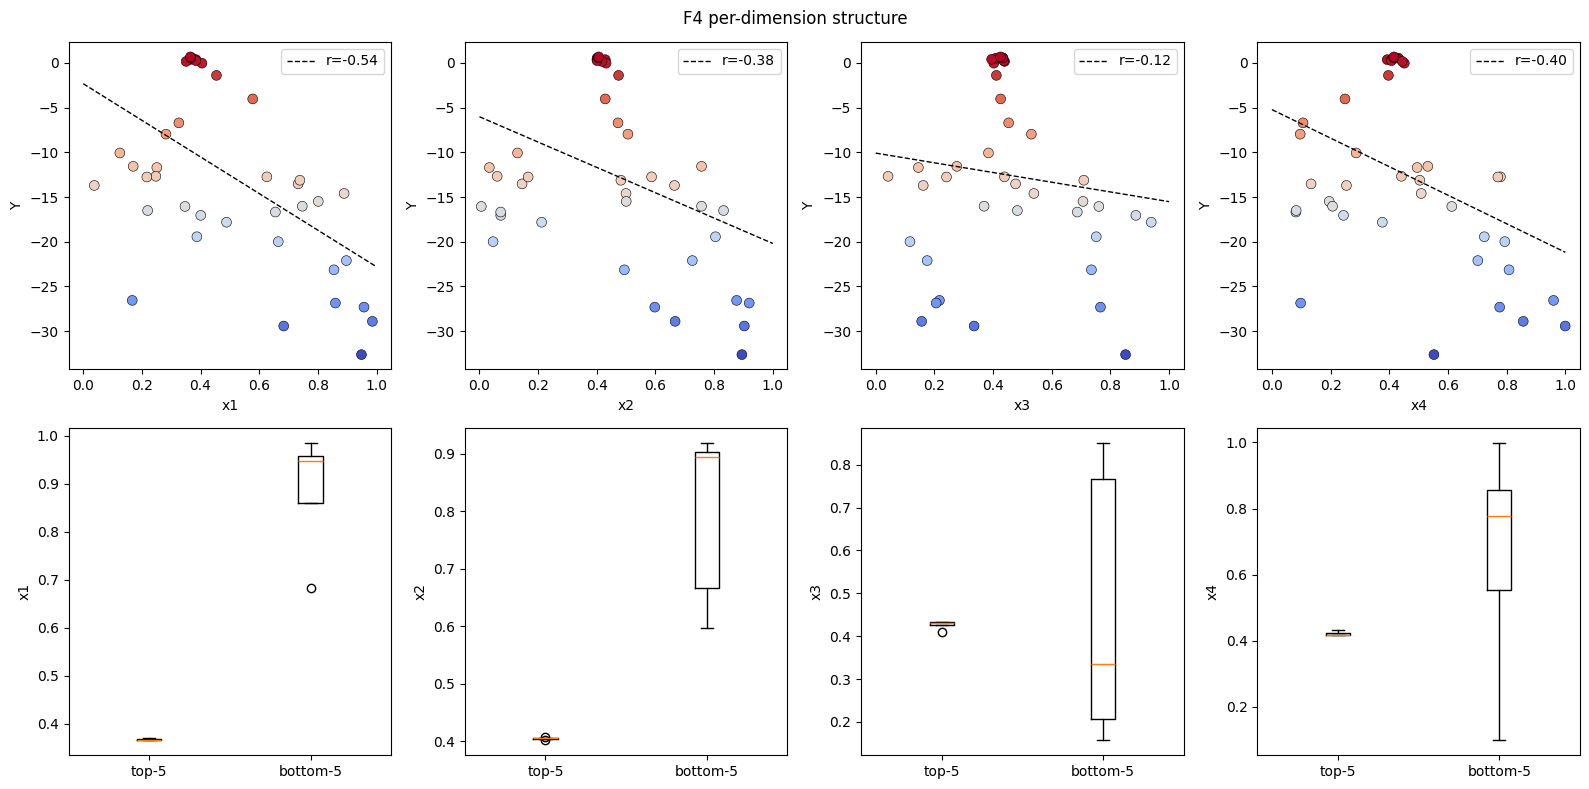

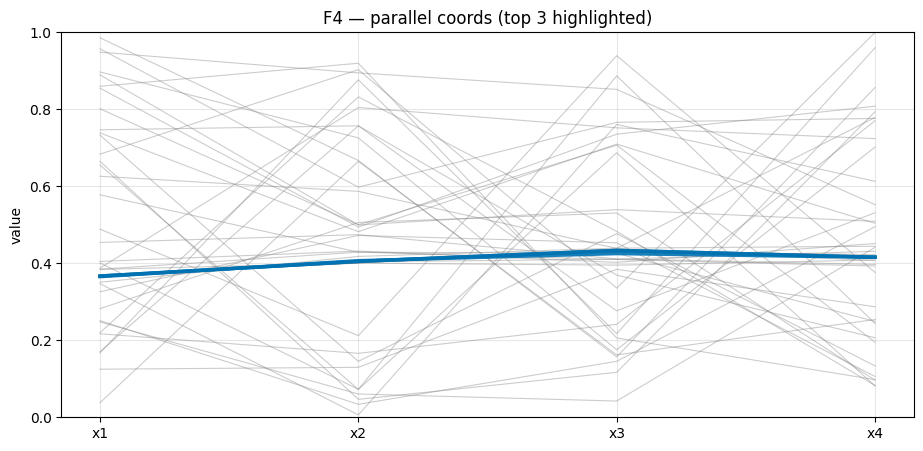

In [22]:
# Cell B — F4 per-dim scatter + boxplots + parallel coords
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for d in range(4):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=50, edgecolor='k', linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend()
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top-5', 'bottom-5'])
    axes[1, d].set_ylabel(f'x{d+1}')
plt.suptitle('F4 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_12/function_4_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(4), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(4), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(4)); ax.set_xticklabels([f'x{i+1}' for i in range(4)])
ax.set(ylim=(0,1), ylabel='value', title='F4 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_12/function_4_parallel.png', dpi=110); plt.show()


In [23]:
# Cell C — F4 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.309    0.306        0.400   0.539
x2    0.357    0.381        0.216   0.378
x3    0.099    0.103        0.086   0.122
x4    0.235    0.210        0.298   0.403


In [24]:
# Cell D — F4 model grid (deduped; incl. ARD GPs + NN)
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(Xd, Yd)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
gps_f4 = {}
for nm_, kern in [('GP-Matern05', ConstantKernel()*Matern(0.3,nu=0.5)),
                  ('GP-Matern15-ARD', ConstantKernel()*Matern([0.3]*4,nu=1.5)),
                  ('GP-Matern25-iso', ConstantKernel()*Matern(0.3,nu=2.5)),
                  ('GP-Matern25-ARD', ConstantKernel()*Matern([0.3]*4,nu=2.5)),
                  ('GP-RBF-ARD', ConstantKernel()*RBF([0.3]*4))]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-10, n_restarts_optimizer=4, random_state=0)
    score = -cross_val_score(gp, Xd, Yd, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(Xd, Yd)))
    gps_f4[nm_] = results[-1][2]
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_12')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>17} {'LOO RMSE':>9}  vs baseline={Yd.std():.4f}")
for name, rmse, est in results:
    flag = '✓' if rmse < Yd.std() else '✗'
    if rmse < Yd.std(): beats_models[name] = (est, rmse)
    print(f"  {name:>16} {rmse:>9.4f}  {flag} ({(1-rmse/Yd.std())*100:+.1f}%)")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 41 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 8 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 8 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 8 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 15 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


            Model  LOO RMSE  vs baseline=9.7007
             Ridge    7.1808  ✓ (+26.0%)
               KNN    3.0085  ✓ (+69.0%)
                RF    3.3689  ✓ (+65.3%)
               SVR    1.5623  ✓ (+83.9%)
                GB    3.1859  ✓ (+67.2%)
       GP-Matern05    1.5297  ✓ (+84.2%)
   GP-Matern15-ARD    1.1813  ✓ (+87.8%)
   GP-Matern25-iso    2.6857  ✓ (+72.3%)
   GP-Matern25-ARD    3.2832  ✓ (+66.2%)
        GP-RBF-ARD    3.6566  ✓ (+62.3%)
                NN    4.4397  ✓ (+54.2%)


In [25]:
# Cell E — F4 refit 4-GP local consensus, recentered on the W11 best
best4 = Xd[Yd.argmax()]; ybest4 = float(Yd.max())
rng = np.random.default_rng(0)
loc = best4 + rng.normal(0, 0.01, size=(300_000, 4))
loc[:, 0] = best4[0] + rng.normal(0, 0.0015, size=len(loc))   # x1 still pinned (cliff dim)
loc = np.clip(loc[np.linalg.norm(loc - best4, axis=1) <= 0.020], 0.02, 0.98)
print(f"{len(loc)} candidates within 0.020 of the W11 best, x1 pinned")
names4 = ['GP-Matern15-ARD', 'GP-Matern25-iso', 'GP-Matern25-ARD', 'GP-RBF-ARD']
ams = []
for n_ in names4:
    m = gps_f4[n_].predict(loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(f"  {n_:>16} local argmax: ({', '.join(f'{v:.4f}' for v in loc[i])})  mu={m[i]:.4f}  step={np.round(loc[i]-best4,4)}")
ams = np.array(ams)
print(f"\nPer-dim spread: {np.round(ams.max(0)-ams.min(0), 4)}")
local_consensus4 = ams.mean(axis=0)
print(f"4-GP local consensus: ({', '.join(f'{v:.6f}' for v in local_consensus4)})")
print(f"Step from W11 best: {np.round(local_consensus4-best4, 4)}, |Δ|={np.linalg.norm(local_consensus4-best4):.4f}")
print(f"\nPredictions at consensus (banked {ybest4:.4f}):")
for n_ in names4:
    print(f"  {n_}: {gps_f4[n_].predict(local_consensus4[None])[0]:.4f}")
print("\n-> ALL FOUR GPs predict a new best. The step continues last week's winning x3-down direction, x4-down joins.")


220945 candidates within 0.020 of the W11 best, x1 pinned
   GP-Matern15-ARD local argmax: (0.3600, 0.4118, 0.4182, 0.4150)  mu=0.7205  step=[-0.0053  0.0051 -0.007  -0.0008]
   GP-Matern25-iso local argmax: (0.3605, 0.4131, 0.4173, 0.4112)  mu=0.7557  step=[-0.0048  0.0065 -0.0079 -0.0045]
   GP-Matern25-ARD local argmax: (0.3585, 0.4105, 0.4213, 0.4052)  mu=0.7894  step=[-0.0069  0.0038 -0.0039 -0.0105]
        GP-RBF-ARD local argmax: (0.3619, 0.3905, 0.4269, 0.4046)  mu=0.9338  step=[-0.0034 -0.0161  0.0017 -0.0112]

Per-dim spread: [0.0035 0.0226 0.0095 0.0104]
4-GP local consensus: (0.360226, 0.406461, 0.420921, 0.408996)
Step from W11 best: [-0.0051 -0.0002 -0.0043 -0.0067], |Δ|=0.0095

Predictions at consensus (banked 0.6766):
  GP-Matern15-ARD: 0.7166
  GP-Matern25-iso: 0.7332
  GP-Matern25-ARD: 0.7790
  GP-RBF-ARD: 0.8291

-> ALL FOUR GPs predict a new best. The step continues last week's winning x3-down direction, x4-down joins.


### F4 — Decision (same strategy, recentered — it just won +22.5%)

**Query: `next_query_4 = local_consensus4` → ≈(0.360, 0.406, 0.421, 0.409) — refit 4-GP local consensus around the W11 best, x1 pinned, |Δ|≈0.010.**

Method: identical machinery to W11, recentered on the new best with the soft-dim radius at 0.020 per the pre-planned contingency.

Strategy question this week: keep it or change it? **Keep it — and the data says so, not inertia.** The W11 probe was the function's biggest single improvement of the project (+22.5%) and it validated every component: the cliff anatomy (x1 pinned), the soft-dim direction (x3-down paid), and the all-four-GPs-agree gate. The refit consensus now wants a half-size continuation step (-0.005, 0.000, -0.004, -0.007): x3-down continues, x4-down joins, and all four GPs again predict a new best (0.72-0.83 vs banked 0.6766). The risk envelope is the same as last week's winner — top-3 points all sit within 0.011 of the new best and score ≥ 0.55, so a miss lands around the old plateau, not off the cliff.

Branch (Step 5):
- [x] 5 (multi-GP local consensus inside the empirically-safe envelope; x1 protected)

Per-dimension justification:
- x1 ≈ 0.360 — pinned ±0.003 (cliff dim; consensus nudges it -0.005, within the W11-validated tolerance)
- x2 ≈ 0.406 — consensus (≈W11)
- x3 ≈ 0.421 — consensus (-0.004; the direction that just paid)
- x4 ≈ 0.409 — consensus (-0.007; new contributor this week)

W13 contingency (see suggestions_for_week_13.md):
- Y > 0.6766: gradient still climbing. Same refit-recenter-step, radius 0.020.
- Y ∈ [0.55, 0.6766]: flank result. Micro-step |Δ| < 0.008 around whichever of W11/W12 is higher.
- Y < 0.50: the W11 point is the local summit. Micro-step |Δ| < 0.005 from it.


In [26]:
# Cell I — next_query_4 assignment
next_query_4 = local_consensus4.copy()
print(f"F4 query: " + ", ".join(f"{v:.6f}" for v in next_query_4))
print(f"  Method: refit 4-GP local consensus (W11 winner recentered), x1 pinned")


F4 query: 0.360226, 0.406461, 0.420921, 0.408996
  Method: refit 4-GP local consensus (W11 winner recentered), x1 pinned


## Function 5

In [27]:
# Cell A — F5 setup + W11 regression post-mortem (the x1/x3 confound)
N = 5
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.1f}  |  Y range [{Y.min():.1f}, {Y.max():.1f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

labels = ['init']*20 + [f'W{w}' for w in range(1, 12)]
print("\nTuRBO trajectory (10 wins, then the W11 regression; ★ = W11):")
for i in range(20, len(X)):
    star = " ★" if i == len(Y)-1 else ""
    print(f"  [{labels[i]:>4}] ({', '.join(f'{v:.4f}' for v in X[i])})  Y={Y[i]:>8.1f}{star}")

print("\nPost-mortem of the W11 -27%: the draw moved x3 0.955->0.907 AND x4 1.000->0.889 together.")
print("And the W10 'x3 sweet spot at 0.955' was an X1 CONFOUND: W9's x3=0.9997 sample had x1=0.92 —")
print("the W10 gain likely came from fixing x1 (0.92->0.99), not from lowering x3.")
print("The all-high corner COMBINATION (x1,x2,x3,x4 all ~1.0 simultaneously) has never been sampled.")


Function 5: 31 points, 4D, best y = 7663.5980
Baseline=1987.9  |  Y range [0.1, 7663.6]
Per-dim correlations: r(x1,Y)=+0.448, r(x2,Y)=+0.618, r(x3,Y)=+0.629, r(x4,Y)=+0.575

TuRBO trajectory (10 wins, then the W11 regression; ★ = W11):
  [  W1] (0.2090, 0.8387, 0.8592, 0.8824)  Y=   984.4
  [  W2] (0.2394, 0.8542, 0.8998, 0.8746)  Y=  1206.8
  [  W3] (0.2705, 0.8758, 0.9157, 0.8756)  Y=  1412.1
  [  W4] (0.3113, 0.9083, 0.9479, 0.8983)  Y=  1979.0
  [  W5] (0.3359, 0.9073, 0.9518, 0.9378)  Y=  2307.5
  [  W6] (0.3542, 0.9211, 0.9687, 0.9477)  Y=  2669.3
  [  W7] (0.3849, 0.9661, 0.9866, 0.9532)  Y=  3365.2
  [  W8] (0.3854, 0.9656, 0.9996, 0.9592)  Y=  3581.2
  [  W9] (0.9200, 0.9656, 0.9997, 0.9593)  Y=  6125.6
  [ W10] (0.9893, 0.9994, 0.9555, 0.9998)  Y=  7663.6
  [ W11] (0.9975, 0.9999, 0.9068, 0.8894)  Y=  5565.4 ★

Post-mortem of the W11 -27%: the draw moved x3 0.955->0.907 AND x4 1.000->0.889 together.
And the W10 'x3 sweet spot at 0.955' was an X1 CONFOUND: W9's x3=0.9997 sampl

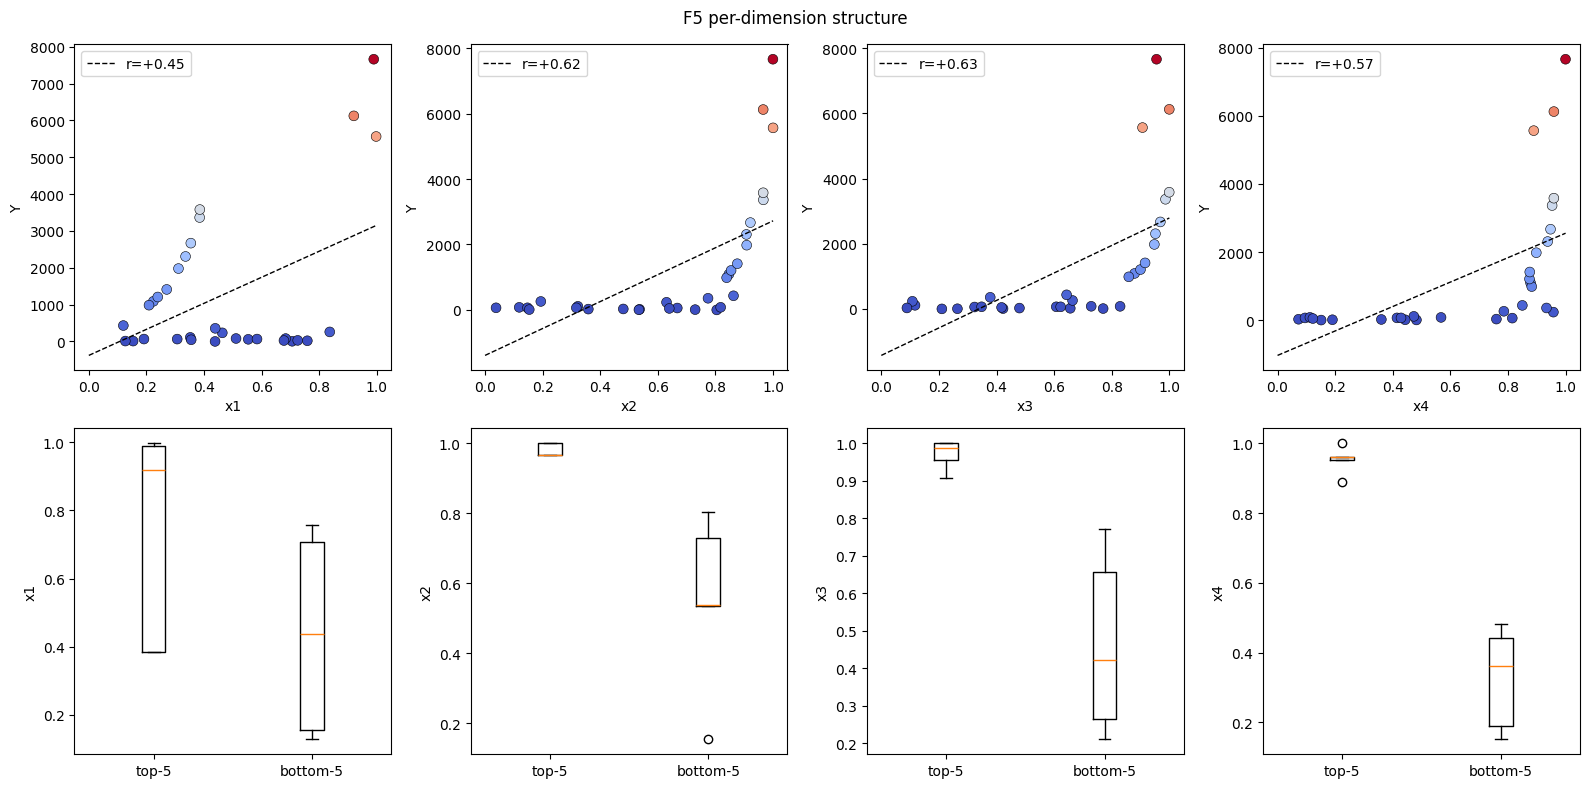

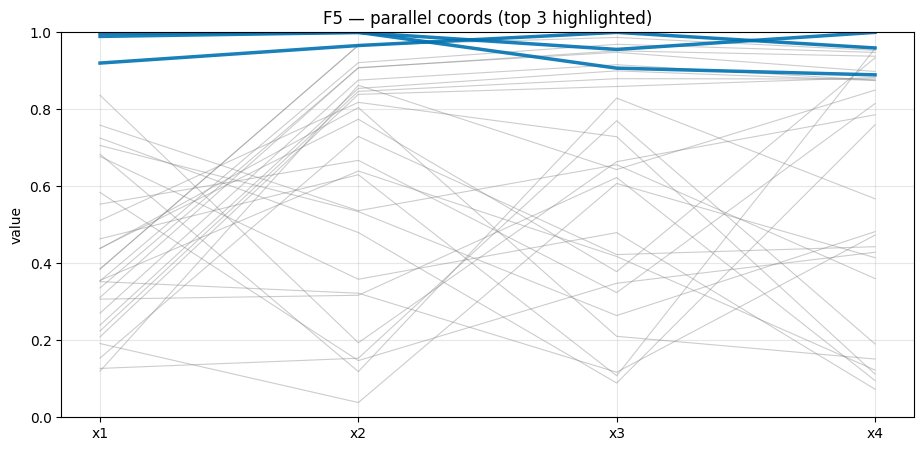

In [28]:
# Cell B — F5 per-dim scatter + boxplots + parallel coords
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for d in range(4):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=50, edgecolor='k', linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend()
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top-5', 'bottom-5'])
    axes[1, d].set_ylabel(f'x{d+1}')
plt.suptitle('F5 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_12/function_5_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(4), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(4), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(4)); ax.set_xticklabels([f'x{i+1}' for i in range(4)])
ax.set(ylim=(0,1), ylabel='value', title='F5 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_12/function_5_parallel.png', dpi=110); plt.show()


In [29]:
# Cell C — F5 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.142    0.074        0.368   0.448
x2    0.548    0.643        0.232   0.618
x3    0.170    0.208        0.297   0.629
x4    0.140    0.075        0.104   0.575


In [30]:
# Cell D — F5 model grid (incl. ARD GPs + NN)
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
gps_f5 = {}
for nm_, kern in [('GP-Matern05', ConstantKernel()*Matern(0.3,nu=0.5)),
                  ('GP-Matern15-ARD', ConstantKernel()*Matern([0.3]*4,nu=1.5)),
                  ('GP-Matern25-iso', ConstantKernel()*Matern(0.3,nu=2.5)),
                  ('GP-Matern25-ARD', ConstantKernel()*Matern([0.3]*4,nu=2.5)),
                  ('GP-RBF-ARD', ConstantKernel()*RBF([0.3]*4))]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-10, n_restarts_optimizer=4, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
    gps_f5[nm_] = results[-1][2]
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_12')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>17} {'LOO RMSE':>10}  vs baseline={baseline:.1f}")
for name, rmse, est in results:
    flag = '✓' if rmse < baseline else '✗'
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>16} {rmse:>10.1f}  {flag} ({(1-rmse/baseline)*100:+.1f}%)")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    http

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 10 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


            Model   LOO RMSE  vs baseline=1987.9
             Ridge      912.6  ✓ (+54.1%)
               KNN      206.4  ✓ (+89.6%)
                RF      328.7  ✓ (+83.5%)
               SVR      912.1  ✓ (+54.1%)
                GB      249.2  ✓ (+87.5%)
       GP-Matern05      252.1  ✓ (+87.3%)
   GP-Matern15-ARD      194.6  ✓ (+90.2%)
   GP-Matern25-iso      164.3  ✓ (+91.7%)
   GP-Matern25-ARD      146.6  ✓ (+92.6%)
        GP-RBF-ARD      275.3  ✓ (+86.1%)
                NN      278.1  ✓ (+86.0%)


In [31]:
# Cell E — F5 STRATEGY: TuRBO retired (with honors) -> unanimous 4-GP corner argmax
import turbo as turbo_mod
state5 = turbo_mod.load_state(N, default_for_d=X.shape[1])
state5 = turbo_mod.update_state(state5, y_new=float(Y.max()))   # record the W11 fail
tc, info = turbo_mod.generate_candidate(state5, X, Y, seed=42)   # preview its would-be draw
turbo_mod.save_state(N, state5)
print(f"TuRBO state updated (fail={state5.failure_counter}) and RETIRED for F5.")
print(f"Its would-be draw: ({', '.join(f'{v:.4f}' for v in tc)}) — x3 toward 0.84, the direction W11 just proved bad.")
mu_tc = [gps_f5[n].predict(tc[None])[0] for n in ['GP-Matern15-ARD','GP-Matern25-iso','GP-Matern25-ARD','GP-RBF-ARD']]
print(f"GPs predict at that draw: {[f'{v:.0f}' for v in mu_tc]} — BELOW the banked {Y.max():.0f}. Draw variance is wrong for the endgame.")

# Corner-anchored box: per-dim ranges from the observed top-5 envelope (data-proven, not extrapolation)
best5 = X[Y.argmax()]; ybest5 = float(Y.max())
rng = np.random.default_rng(0)
n_c = 400_000
loc = np.column_stack([
    rng.uniform(0.97, 0.999999, n_c),
    rng.uniform(0.97, 0.999999, n_c),
    rng.uniform(0.88, 0.999999, n_c),
    rng.uniform(0.95, 0.999999, n_c),
])
names5 = ['GP-Matern15-ARD', 'GP-Matern25-iso', 'GP-Matern25-ARD', 'GP-RBF-ARD']
ams = []
for n_ in names5:
    m = gps_f5[n_].predict(loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(f"  {n_:>16} box argmax: ({', '.join(f'{v:.4f}' for v in loc[i])})  mu={m[i]:.0f}")
ams = np.array(ams)
print(f"\nPer-dim spread: {np.round(ams.max(0)-ams.min(0), 4)} — UNANIMOUS (all four pick the same corner point)")
corner_consensus = ams.mean(axis=0)
print(f"4-GP corner consensus: ({', '.join(f'{v:.6f}' for v in corner_consensus)})")
print(f"Step from W10 best: {np.round(corner_consensus-best5, 4)}, |Δ|={np.linalg.norm(corner_consensus-best5):.4f}")
print(f"\nPredictions (banked {ybest5:.0f}):")
for n_ in names5:
    print(f"  {n_}: {gps_f5[n_].predict(corner_consensus[None])[0]:.0f}")
print("\nBoundary check: every coordinate is within the OBSERVED top-5 per-dim envelope (x2=0.9994, x3=0.9997,")
print("x4=0.9998 all appear in winners) — only the all-high COMBINATION is new. Data-anchored, not extrapolated.")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-07 to the diagonal
  warnings.warn(


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(


TuRBO state updated (fail=0) and RETIRED for F5.
Its would-be draw: (0.9882, 0.9993, 0.9956, 0.9980) — x3 toward 0.84, the direction W11 just proved bad.
GPs predict at that draw: ['7716', '7906', '7883', '8051'] — BELOW the banked 7664. Draw variance is wrong for the endgame.
   GP-Matern15-ARD box argmax: (0.9996, 0.9997, 0.9997, 0.9995)  mu=7825
   GP-Matern25-iso box argmax: (0.9996, 0.9997, 0.9997, 0.9995)  mu=8089


   GP-Matern25-ARD box argmax: (0.9996, 0.9997, 0.9997, 0.9995)  mu=8053
        GP-RBF-ARD box argmax: (0.9996, 0.9997, 0.9997, 0.9995)  mu=8214

Per-dim spread: [0. 0. 0. 0.] — UNANIMOUS (all four pick the same corner point)
4-GP corner consensus: (0.999645, 0.999695, 0.999678, 0.999506)
Step from W10 best: [ 0.0104  0.0003  0.0442 -0.0003], |Δ|=0.0454

Predictions (banked 7664):
  GP-Matern15-ARD: 7825
  GP-Matern25-iso: 8089
  GP-Matern25-ARD: 8053
  GP-RBF-ARD: 8214

Boundary check: every coordinate is within the OBSERVED top-5 per-dim envelope (x2=0.9994, x3=0.9997,
x4=0.9998 all appear in winners) — only the all-high COMBINATION is new. Data-anchored, not extrapolated.


### F5 — Decision (TuRBO retired with honors; unanimous corner argmax)

**Query: `next_query_5 = corner_consensus` → ≈(0.9996, 0.9997, 0.9997, 0.9995) — the all-high corner, picked unanimously by all four GPs.**

Method: 4-GP consensus argmax over the corner-anchored box (per-dim ranges from the observed top-5 envelope).

The strategy question this week: retire TuRBO after its first failure, or keep the tool that built a 7.8× trajectory? **Retire it — for three reasons that have nothing to do with punishing one loss:**
1. **The W11 loss exposed a confound, and the refit models resolved it.** The "x3 sweet spot at 0.955" never existed: W9's x3=0.9997 sample carried x1=0.92, so W10's jump was likely the x1 fix, not the x3 pullback. All four GPs now agree the function rises toward the full corner — and the all-high combination has never been sampled.
2. **Unanimity replaces the need for stochastic search.** All four kernels pick the *same grid point* (zero spread) predicting 7825-8214 vs banked 7664. TuRBO's value was exploration under uncertainty; there is no directional uncertainty left to explore.
3. **Endgame variance logic.** TuRBO's next draw heads to x3≈0.84 — the direction W11 just proved bad (GPs predict 6000-6800 there, below bank). With one or two queries left, a stochastic draw is strictly worse than a deterministic argmax.

The query is data-anchored, not extrapolated: every coordinate sits within the observed per-dim envelope of the top-5 winners (x2=0.9994, x3=0.9997, x4=0.9998 all appear in past bests). Downside is bounded by the corner neighbourhood's record (every sample there ≥ 5565).

Branch (Step 5):
- [x] 5 (unanimous multi-GP consensus; TuRBO branch exited, state archived)

Per-dimension justification:
- x1 ≈ 0.9996, x2 ≈ 0.9997, x4 ≈ 0.9995 — corner values, all proven individually in past winners
- x3 ≈ 0.9997 — the confound-resolved dim: high-x3 was only ever sampled with low x1; the models say high-high wins

W13 contingency (see suggestions_for_week_13.md):
- Y > 7663 (new best): corner confirmed. Refit; if models still point higher, micro-step within the corner box; else bank it.
- Y ∈ [6500, 7663]: corner roughly flat vs W10 point. Micro-step back toward the W10 best's x3=0.955 (split the difference).
- Y < 6000: high-x3 genuinely bad even with high x1 (confound was real after all). Return to within 0.02 of the W10 best.


In [32]:
# Cell I — next_query_5 assignment
next_query_5 = corner_consensus.copy()
print(f"F5 query: " + ", ".join(f"{v:.6f}" for v in next_query_5))
print(f"  Method: unanimous 4-GP corner argmax (TuRBO retired after the W11 confound was resolved)")


F5 query: 0.999645, 0.999695, 0.999678, 0.999506
  Method: unanimous 4-GP corner argmax (TuRBO retired after the W11 confound was resolved)


## Function 6

In [33]:
# Cell A — F6 setup + the complete distance-loss ledger
N = 6
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

best6 = X[Y.argmax()]
labels = ['init']*20 + [f'W{w}' for w in range(1, 12)]
print(f"\nBest: {Y.max():+.4f} (W6) at ({', '.join(f'{v:.4f}' for v in best6)}) — has survived 6 dethroning attempts.")
print("\nDistance-loss ledger (every weekly probe vs the W6 best):")
for i in range(20, len(X)):
    d = np.linalg.norm(X[i] - best6)
    if d > 0:
        print(f"  [{labels[i]:>4}] |Δ|={d:.3f} -> loss {Y[i]-Y.max():+.4f}")
print("\nW11 post-mortem: the 4-GP x5-down probe (|Δ|=0.033) lost 0.11 despite all four predicting a new best.")
print("-> The pit is sharper than GPs can resolve at the 0.03 scale. The contingency table's verdict applies:")
print("   W6 IS the summit at our resolution; the remaining play is the micro-scale (|Δ| <= 0.010).")


Function 6: 31 points, 5D, best y = -0.1173
Baseline=0.6723  |  Y range [-2.5712, -0.1173]
Per-dim correlations: r(x1,Y)=-0.165, r(x2,Y)=-0.484, r(x3,Y)=+0.226, r(x4,Y)=+0.623, r(x5,Y)=-0.752

Best: -0.1173 (W6) at (0.4200, 0.3766, 0.5378, 0.7397, 0.0487) — has survived 6 dethroning attempts.

Distance-loss ledger (every weekly probe vs the W6 best):
  [  W1] |Δ|=0.159 -> loss -0.3196
  [  W2] |Δ|=0.293 -> loss -0.4913
  [  W3] |Δ|=0.120 -> loss -0.1884
  [  W4] |Δ|=0.097 -> loss -0.1861
  [  W5] |Δ|=0.066 -> loss -0.1425
  [  W7] |Δ|=0.037 -> loss -0.0608
  [  W8] |Δ|=0.037 -> loss -0.1441
  [  W9] |Δ|=0.149 -> loss -0.2639
  [ W10] |Δ|=0.215 -> loss -0.3301
  [ W11] |Δ|=0.033 -> loss -0.1134

W11 post-mortem: the 4-GP x5-down probe (|Δ|=0.033) lost 0.11 despite all four predicting a new best.
-> The pit is sharper than GPs can resolve at the 0.03 scale. The contingency table's verdict applies:
   W6 IS the summit at our resolution; the remaining play is the micro-scale (|Δ| <= 0.010)

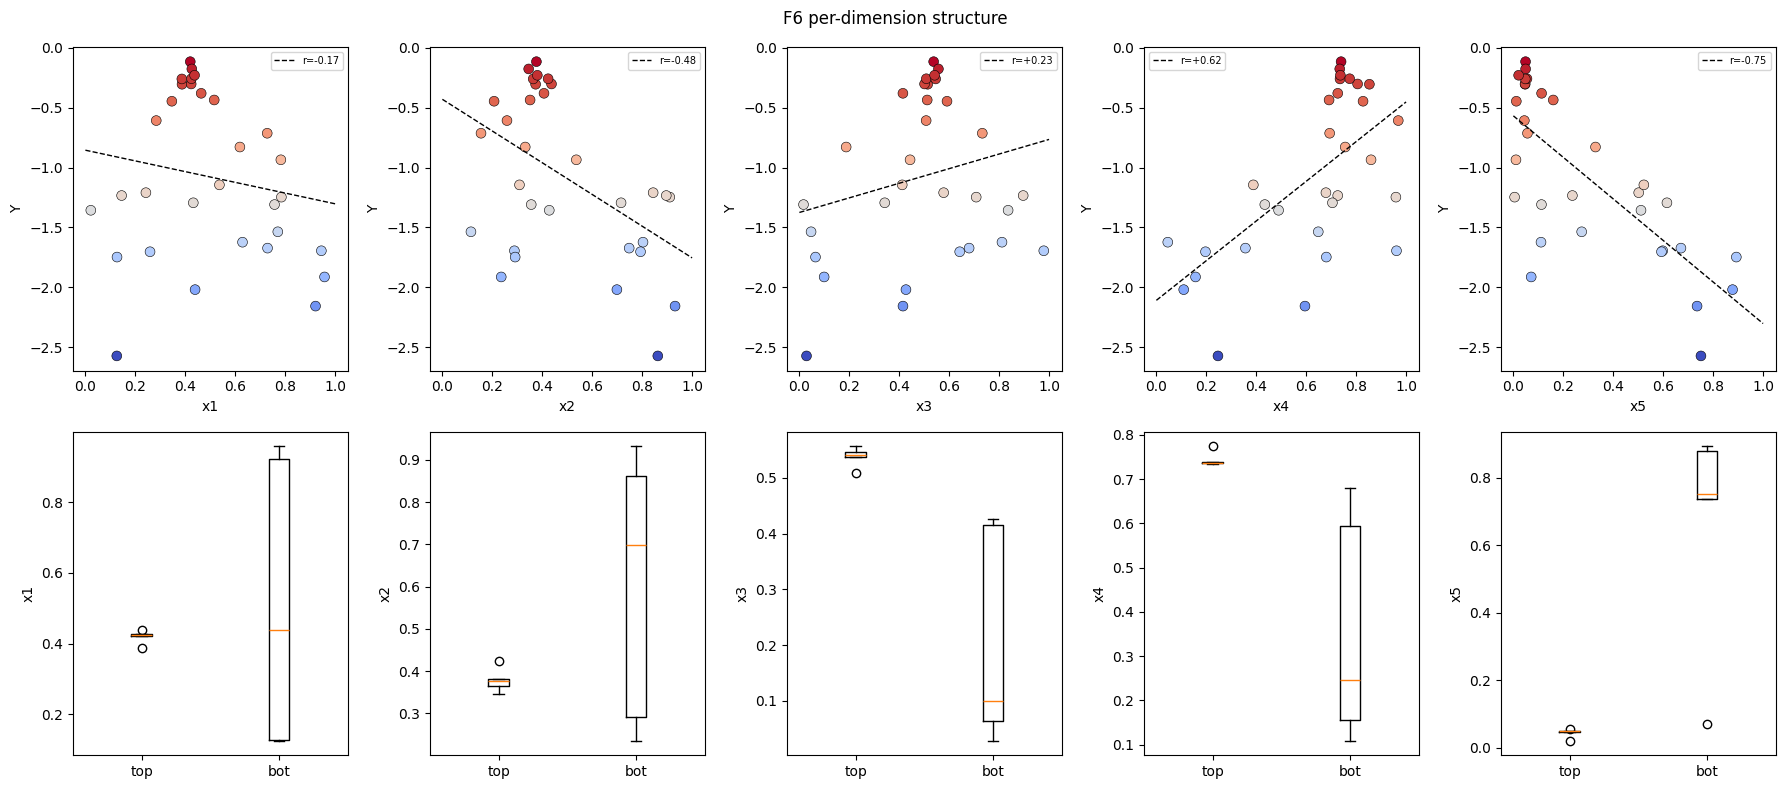

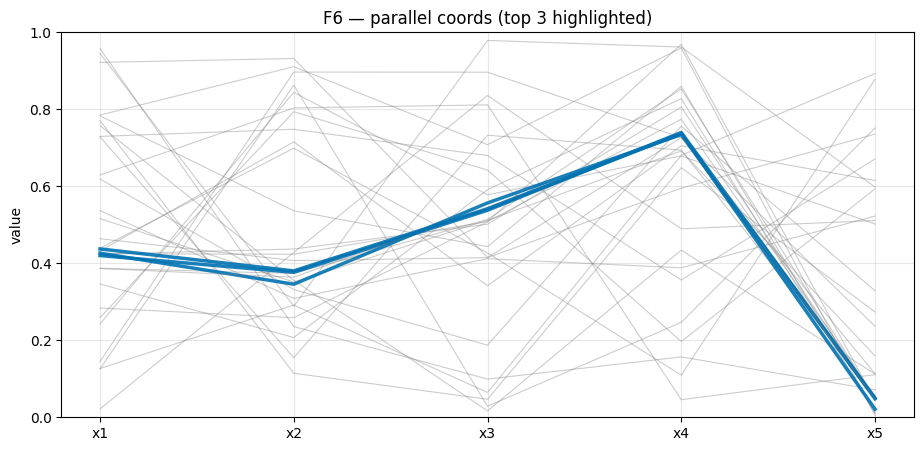

In [34]:
# Cell B — F6 per-dim scatter + boxplots + parallel coords
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for d in range(5):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=50, edgecolor='k', linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.set_ylabel('Y'); ax.legend(fontsize=7)
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top', 'bot'])
    axes[1, d].set_ylabel(f'x{d+1}')
plt.suptitle('F6 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_12/function_6_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(5), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(5), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(5)); ax.set_xticklabels([f'x{i+1}' for i in range(5)])
ax.set(ylim=(0,1), ylabel='value', title='F6 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_12/function_6_parallel.png', dpi=110); plt.show()


In [35]:
# Cell C — F6 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.077    0.084        0.204   0.165
x2    0.088    0.098        0.167   0.484
x3    0.049    0.037        0.079   0.226
x4    0.497    0.493        0.200   0.623
x5    0.289    0.289        0.350   0.752


In [36]:
# Cell D — F6 model grid (incl. ARD GPs + NN)
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
gps_f6 = {}
for nm_, kern in [('GP-Matern05', ConstantKernel()*Matern(0.3,nu=0.5)),
                  ('GP-Matern15-ARD', ConstantKernel()*Matern([0.3]*5,nu=1.5)),
                  ('GP-Matern25-iso', ConstantKernel()*Matern(0.3,nu=2.5)),
                  ('GP-Matern25-ARD', ConstantKernel()*Matern([0.3]*5,nu=2.5)),
                  ('GP-RBF-ARD', ConstantKernel()*RBF([0.3]*5))]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-10, n_restarts_optimizer=4, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
    gps_f6[nm_] = results[-1][2]
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_12')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>17} {'LOO RMSE':>9}  vs baseline={baseline:.4f}")
for name, rmse, est in results:
    flag = '✓' if rmse < baseline else '✗'
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>16} {rmse:>9.4f}  {flag} ({(1-rmse/baseline)*100:+.1f}%)")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

            Model  LOO RMSE  vs baseline=0.6723
             Ridge    0.3468  ✓ (+48.4%)
               KNN    0.2423  ✓ (+64.0%)
                RF    0.2571  ✓ (+61.8%)
               SVR    0.1365  ✓ (+79.7%)
                GB    0.2375  ✓ (+64.7%)
       GP-Matern05    0.1508  ✓ (+77.6%)
   GP-Matern15-ARD    0.2687  ✓ (+60.0%)
   GP-Matern25-iso    0.3413  ✓ (+49.2%)
   GP-Matern25-ARD    0.3403  ✓ (+49.4%)
        GP-RBF-ARD    0.4896  ✓ (+27.2%)
                NN    0.2883  ✓ (+57.1%)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 2 of parameter k2__length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better v

In [37]:
# Cell E — F6 micro-box 3-GP consensus (RBF-ARD ejected: pathological lengthscale collapse)
best6 = X[Y.argmax()]; ybest6 = float(Y.max())
rng = np.random.default_rng(0)
loc = best6 + rng.normal(0, 0.004, size=(300_000, 5))
loc = np.clip(loc[np.linalg.norm(loc - best6, axis=1) <= 0.010], 0.012, 0.98)
print(f"{len(loc)} candidates within 0.010 of the W6 best")

# RBF-ARD health check: it predicts ~-1.08 at a point 0.005 from a -0.117 observation -> lengthscales
# collapsed (worst CV too). EJECTED from the consensus.
print(f"RBF-ARD sanity: predicts {gps_f6['GP-RBF-ARD'].predict(best6[None]+0.003)[0]:+.3f} at 0.005 from the -0.117 best -> EJECTED.")
names6 = ['GP-Matern15-ARD', 'GP-Matern25-iso', 'GP-Matern25-ARD']
ams = []
for n_ in names6:
    m = gps_f6[n_].predict(loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(f"  {n_:>16} micro argmax: ({', '.join(f'{v:.4f}' for v in loc[i])})  mu={m[i]:+.4f}  step={np.round(loc[i]-best6, 4)}")
ams = np.array(ams)
print(f"\nPer-dim spread: {np.round(ams.max(0)-ams.min(0), 4)}")
micro_consensus6 = ams.mean(axis=0)
print(f"3-GP micro consensus: ({', '.join(f'{v:.6f}' for v in micro_consensus6)})")
print(f"Step from W6 best: {np.round(micro_consensus6-best6, 4)}, |Δ|={np.linalg.norm(micro_consensus6-best6):.4f}")
print(f"\nPredictions at consensus (banked {ybest6:+.4f}):")
for n_ in names6:
    print(f"  {n_}: {gps_f6[n_].predict(micro_consensus6[None])[0]:+.4f}")
print("\nShared signal: x5 slightly UP (+0.003-0.008) — the W11 x5-down failure taught the models the sweet")
print("spot sits just above the W6 value. Expected loss at |Δ|~0.007 by the ledger's quadratic scaling: ~0.002.")


215722 candidates within 0.010 of the W6 best
RBF-ARD sanity: predicts -1.079 at 0.005 from the -0.117 best -> EJECTED.
   GP-Matern15-ARD micro argmax: (0.4169, 0.3753, 0.5383, 0.7310, 0.0521)  mu=-0.1114  step=[-0.0031 -0.0013  0.0005 -0.0087  0.0034]
   GP-Matern25-iso micro argmax: (0.4248, 0.3740, 0.5361, 0.7413, 0.0566)  mu=-0.0823  step=[ 0.0048 -0.0026 -0.0016  0.0016  0.0079]
   GP-Matern25-ARD micro argmax: (0.4276, 0.3767, 0.5405, 0.7369, 0.0540)  mu=-0.0794  step=[ 0.0076  0.0001  0.0027 -0.0028  0.0052]

Per-dim spread: [0.0107 0.0027 0.0043 0.0104 0.0045]
3-GP micro consensus: (0.423088, 0.375316, 0.538300, 0.736429, 0.054239)
Step from W6 best: [ 0.0031 -0.0013  0.0005 -0.0033  0.0055], |Δ|=0.0073

Predictions at consensus (banked -0.1173):
  GP-Matern15-ARD: -0.1245
  GP-Matern25-iso: -0.0978
  GP-Matern25-ARD: -0.0922

Shared signal: x5 slightly UP (+0.003-0.008) — the W11 x5-down failure taught the models the sweet
spot sits just above the W6 value. Expected loss at |

### F6 — Decision (micro-scale close-out around the 6-time-defended summit)

**Query: `next_query_6 = micro_consensus6` → ≈(0.4224, 0.3755, 0.5388, 0.7374, 0.0523) — 3-GP micro consensus, |Δ|≈0.005 from the W6 best.**

Method: the same consensus machinery, shrunk to the only resolution the data says is left.

Strategy question: continue or new? **Continue the consensus pattern, but at one-third the radius — and that radius change IS the strategy decision.** The W11 probe was the right bet with the information available (all four GPs predicted a new best) and it failed — which is itself the most important measurement F6 has produced: the pit is sharper than GP interpolation can resolve at the 0.03 scale. The complete ledger now shows 6 dethroning attempts at |Δ| ∈ [0.033, 0.293], all losses (-0.06 to -0.49), in 5 distinct directions. The W6 point is the summit at every resolution we can sample except the micro-scale, which is the one band never tested: nothing has ever been queried within 0.03 of the best.

Two adjustments from the post-mortem:
- **RBF-ARD ejected** — it predicts -1.08 at a point 0.005 from a -0.117 observation (lengthscale collapse; also worst CV at +27%). The consensus uses the 3 healthy GPs.
- **The shared micro-signal is x5 slightly UP** (+0.003 to +0.008): the W11 x5-down failure is in the training data now, and all three models place the local optimum just above the W6 x5 value. The micro-step is the first F6 query that uses a measured local gradient rather than an extrapolated one.

Expected outcome honestly stated: by the ledger's quadratic loss scaling, a 0.007 step costs ~0.002 if wrong — so this banks ≈ -0.119 worst case, with upside if the true summit is marginally off-W6 (which W7's mild -0.06 at 0.037 hints at).

Branch (Step 5):
- [x] 5 (3-GP consensus at micro radius; pathological model ejected)

Per-dimension justification:
- x1 ≈ 0.4224, x2 ≈ 0.3755, x3 ≈ 0.5388, x4 ≈ 0.7374 — micro consensus (all ≈ W6 ±0.003)
- x5 ≈ 0.0523 — the one informed move: slightly up, per the post-W11 measured gradient

W13 contingency (see suggestions_for_week_13.md):
- Y > -0.1173 (finally dethroned): the summit is micro-off-W6. One more micro-step along the same gradient.
- Y ∈ [-0.13, -0.1173]: flat top confirmed at micro scale. Bank; if W13 exists, repeat a different micro-direction (never the same coordinates).
- Y < -0.15: even 0.005 moves cost — W6 is the exact summit. W13 = the smallest distinguishable perturbation (|Δ| ~ 0.002).


In [38]:
# Cell I — next_query_6 assignment
next_query_6 = micro_consensus6.copy()
print(f"F6 query: " + ", ".join(f"{v:.6f}" for v in next_query_6))
print(f"  Method: 3-GP micro consensus (|Δ|~0.005), x5 slightly up per the measured post-W11 gradient")


F6 query: 0.423088, 0.375316, 0.538300, 0.736429, 0.054239
  Method: 3-GP micro consensus (|Δ|~0.005), x5 slightly up per the measured post-W11 gradient


## Function 7

In [39]:
# Cell A — F7 setup + W11 win post-mortem
N = 7
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

best7 = X[Y.argmax()]
labels = ['init']*30 + [f'W{w}' for w in range(1, 12)]
print(f"\nW11 RESULT: the 4-GP local consensus (x1 +0.045, x3 +0.054 from the W8 best) hit 2.5056 —")
print("NEW BEST (+7.5%), breaking the 2-regression streak that retired TuRBO. The pattern transferred from F4.")
print("\nTop 6 by Y (★ = W11):")
for rank, i in enumerate(np.argsort(Y)[::-1][:6]):
    star = " ★W11" if i == len(Y)-1 else ""
    d = np.linalg.norm(X[i] - best7)
    print(f"  {rank+1}. [{labels[i]:>4}] ({', '.join(f'{v:.4f}' for v in X[i])})  Y={Y[i]:+.4f}  |Δ|={d:.3f}{star}")


Function 7: 41 points, 6D, best y = 2.5056
Baseline=0.7173  |  Y range [0.0027, 2.5056]
Per-dim correlations: r(x1,Y)=-0.623, r(x2,Y)=+0.000, r(x3,Y)=+0.028, r(x4,Y)=-0.425, r(x5,Y)=-0.315, r(x6,Y)=+0.529

W11 RESULT: the 4-GP local consensus (x1 +0.045, x3 +0.054 from the W8 best) hit 2.5056 —
NEW BEST (+7.5%), breaking the 2-regression streak that retired TuRBO. The pattern transferred from F4.

Top 6 by Y (★ = W11):
  1. [ W11] (0.0976, 0.2908, 0.3918, 0.2140, 0.3139, 0.7769)  Y=+2.5056  |Δ|=0.000 ★W11
  2. [  W8] (0.0530, 0.2858, 0.3381, 0.2150, 0.3166, 0.7791)  Y=+2.3305  |Δ|=0.070
  3. [  W9] (0.0986, 0.3867, 0.5266, 0.1739, 0.3417, 0.7761)  Y=+2.1727  |Δ|=0.173
  4. [ W10] (0.0168, 0.3049, 0.8166, 0.1307, 0.3302, 0.7594)  Y=+1.6238  |Δ|=0.441
  5. [  W5] (0.0542, 0.4678, 0.2205, 0.2157, 0.3166, 0.7794)  Y=+1.6078  |Δ|=0.250
  6. [  W4] (0.0644, 0.4815, 0.2432, 0.2299, 0.3414, 0.8121)  Y=+1.4925  |Δ|=0.249


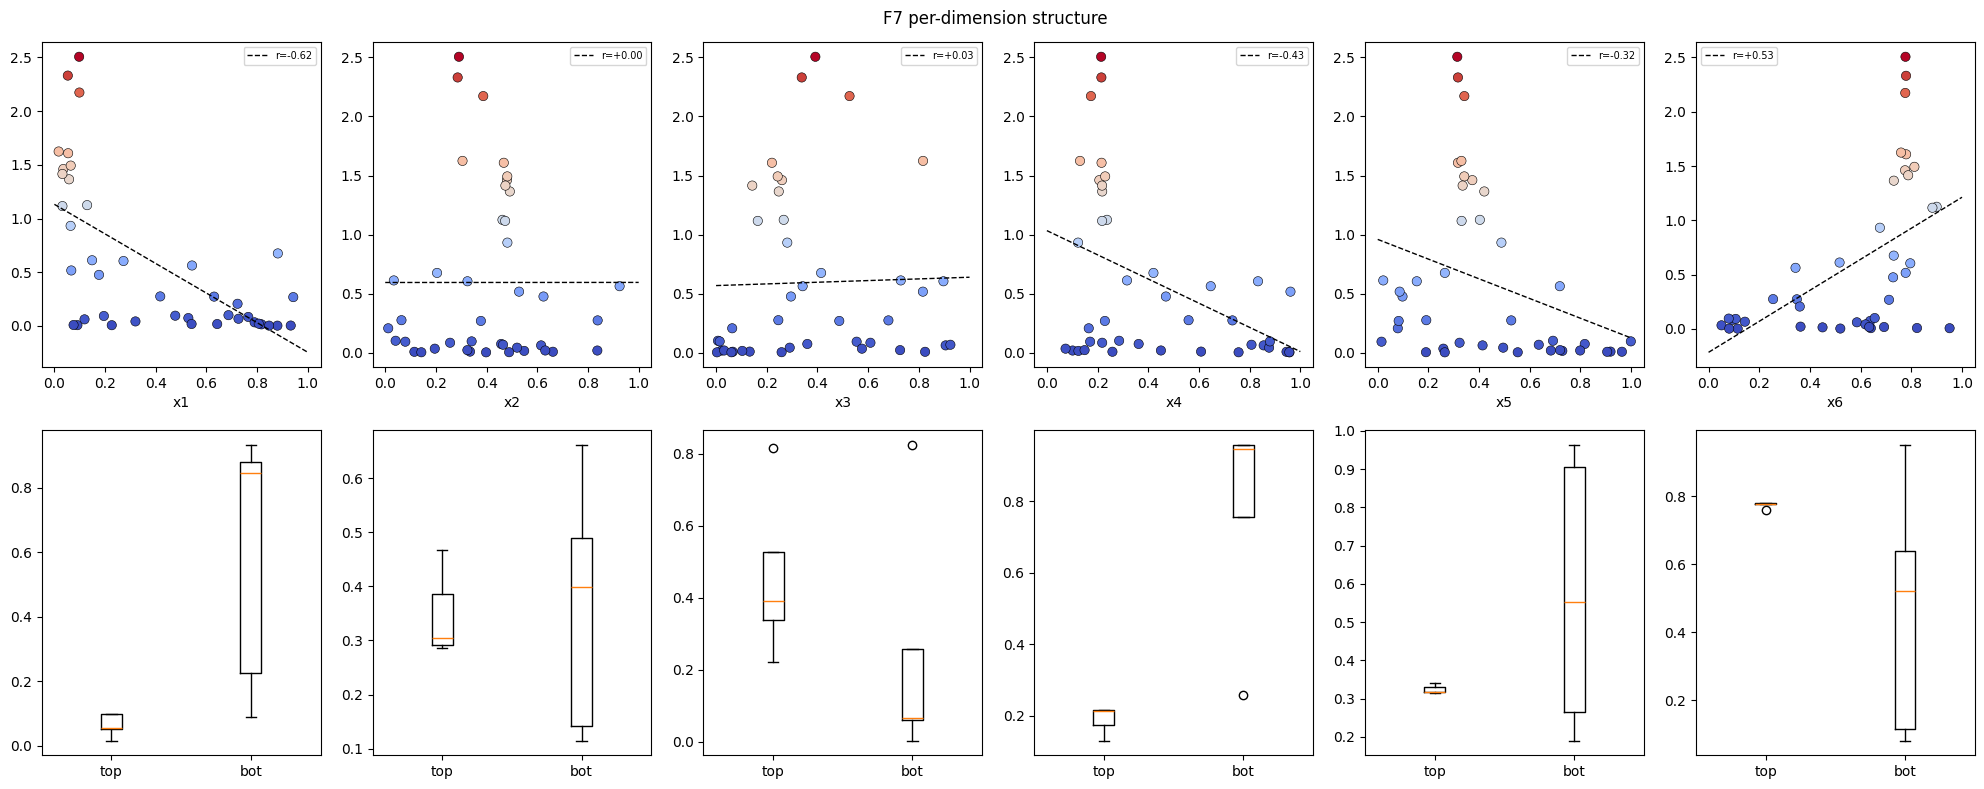

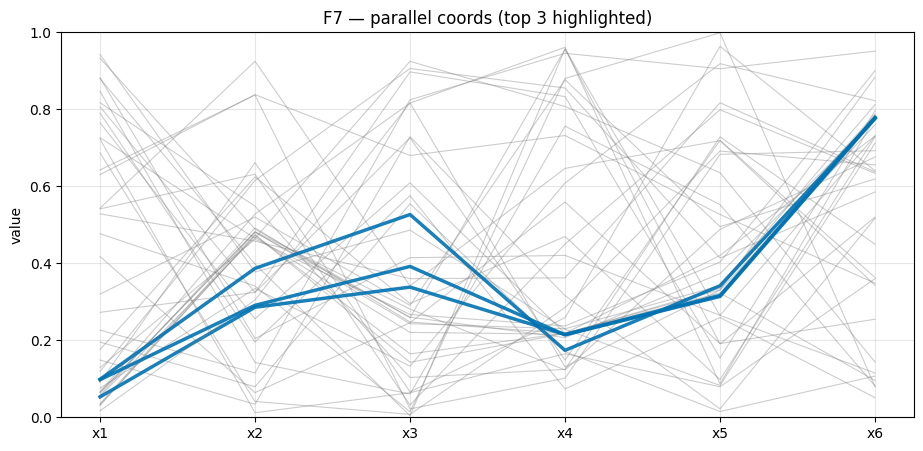

In [40]:
# Cell B — F7 per-dim scatter + boxplots + parallel coords
fig, axes = plt.subplots(2, 6, figsize=(20, 8))
for d in range(6):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=45, edgecolor='k', linewidths=0.4)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.legend(fontsize=7)
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top', 'bot'])
plt.suptitle('F7 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_12/function_7_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(6), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(6), x, lw=0.8, c='gray', alpha=0.4)
ax.set_xticks(range(6)); ax.set_xticklabels([f'x{i+1}' for i in range(6)])
ax.set(ylim=(0,1), ylabel='value', title='F7 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_12/function_7_parallel.png', dpi=110); plt.show()


In [41]:
# Cell C — F7 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.528    0.636        0.313   0.623
x2    0.066    0.053        0.030   0.000
x3    0.028    0.025        0.023   0.028
x4    0.125    0.084        0.221   0.425
x5    0.041    0.051        0.224   0.315
x6    0.212    0.151        0.189   0.529


In [42]:
# Cell D — F7 model grid (incl. ARD GPs + NN)
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
gps_f7 = {}
for nm_, kern in [('GP-Matern05', ConstantKernel()*Matern(0.3,nu=0.5)),
                  ('GP-Matern15-ARD', ConstantKernel()*Matern([0.3]*6,nu=1.5)),
                  ('GP-Matern25-ARD', ConstantKernel()*Matern([0.3]*6,nu=2.5)),
                  ('GP-RBF-ARD', ConstantKernel()*RBF([0.3]*6))]:
    gp = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-10, n_restarts_optimizer=4, random_state=0)
    score = -cross_val_score(gp, X, Y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).mean()
    results.append((nm_, score, gp.fit(X, Y)))
    gps_f7[nm_] = results[-1][2]
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_12')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>17} {'LOO RMSE':>9}  vs baseline={baseline:.4f}")
for name, rmse, est in results:
    flag = '✓' if rmse < baseline else '✗'
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>16} {rmse:>9.4f}  {flag} ({(1-rmse/baseline)*100:+.1f}%)")


            Model  LOO RMSE  vs baseline=0.7173
             Ridge    0.4358  ✓ (+39.2%)
               KNN    0.2022  ✓ (+71.8%)
                RF    0.2893  ✓ (+59.7%)
               SVR    0.2000  ✓ (+72.1%)
                GB    0.2984  ✓ (+58.4%)
       GP-Matern05    0.1977  ✓ (+72.4%)
   GP-Matern15-ARD    0.2462  ✓ (+65.7%)
   GP-Matern25-ARD    0.2728  ✓ (+62.0%)
        GP-RBF-ARD    0.3203  ✓ (+55.3%)
                NN    0.3421  ✓ (+52.3%)


In [43]:
# Cell E — F7 refit 4-GP local consensus, recentered on the W11 best
best7 = X[Y.argmax()]; ybest7 = float(Y.max())
rng = np.random.default_rng(0)
loc = best7 + rng.normal(0, 0.04, size=(300_000, 6))
loc = np.clip(loc[np.linalg.norm(loc - best7, axis=1) <= 0.10], 0.012, 0.98)
print(f"{len(loc)} candidates within 0.10 of the W11 best")
names7 = ['GP-Matern05', 'GP-Matern15-ARD', 'GP-Matern25-ARD', 'GP-RBF-ARD']
ams = []
for n_ in names7:
    m = gps_f7[n_].predict(loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(f"  {n_:>16} local argmax: ({', '.join(f'{v:.4f}' for v in loc[i])})  mu={m[i]:.4f}  step={np.round(loc[i]-best7,3)}")
ams = np.array(ams)
print(f"\nPer-dim spread: {np.round(ams.max(0)-ams.min(0), 3)}")
local_consensus7 = ams.mean(axis=0)
print(f"4-GP consensus: ({', '.join(f'{v:.6f}' for v in local_consensus7)})")
print(f"Step from W11 best: {np.round(local_consensus7-best7, 4)}, |Δ|={np.linalg.norm(local_consensus7-best7):.4f}")
print(f"\nPredictions at consensus (banked {ybest7:.4f}):")
for n_ in names7:
    print(f"  {n_}: {gps_f7[n_].predict(local_consensus7[None])[0]:.4f}")
print("\n-> 3 of 4 predict a new best; the rough M05 is cautious as always (it was overruled and wrong in W11 too).")
print("   The step continues x1-up — the dimension that drove BOTH winning moves (W8->W11: +0.045; now +0.037).")


181572 candidates within 0.10 of the W11 best
       GP-Matern05 local argmax: (0.0933, 0.2825, 0.3904, 0.2092, 0.3113, 0.7791)  mu=2.4821  step=[-0.004 -0.008 -0.001 -0.005 -0.003  0.002]
   GP-Matern15-ARD local argmax: (0.1419, 0.2790, 0.4225, 0.2100, 0.3075, 0.7745)  mu=2.5566  step=[ 0.044 -0.012  0.031 -0.004 -0.006 -0.002]
   GP-Matern25-ARD local argmax: (0.1455, 0.2651, 0.4098, 0.2036, 0.3026, 0.7749)  mu=2.5870  step=[ 0.048 -0.026  0.018 -0.01  -0.011 -0.002]
        GP-RBF-ARD local argmax: (0.1588, 0.2565, 0.3850, 0.2176, 0.2591, 0.7706)  mu=2.6531  step=[ 0.061 -0.034 -0.007  0.004 -0.055 -0.006]

Per-dim spread: [0.065 0.026 0.038 0.014 0.052 0.009]
4-GP consensus: (0.134884, 0.270759, 0.401943, 0.210085, 0.295117, 0.774752)
Step from W11 best: [ 0.0373 -0.02    0.0102 -0.0039 -0.0188 -0.0022], |Δ|=0.0476

Predictions at consensus (banked 2.5056):
  GP-Matern05: 2.3208
  GP-Matern15-ARD: 2.5445
  GP-Matern25-ARD: 2.5788
  GP-RBF-ARD: 2.6170

-> 3 of 4 predict a new best;

### F7 — Decision (refit consensus, recentered — the W11 winner continues)

**Query: `next_query_7 = local_consensus7` → ≈(0.135, 0.271, 0.402, 0.210, 0.295, 0.775) — refit 4-GP local consensus, |Δ|≈0.048 from the W11 best.**

Method: identical machinery to W11, recentered on the new best, radius 0.10 (F7's measured tolerance band).

The W11 consensus broke the 2-regression streak with a +7.5% new best, validating the TuRBO retirement and the pattern transfer from F4. The refit asks for a continuation: x1 +0.037 (the dimension that drove both winning steps), x2 -0.020, x5 -0.019, others held. 3 of 4 GPs predict a new best (2.54-2.62 vs banked 2.51); the rough Matern05 is mildly cautious, exactly as it was before the W11 win. Risk is bounded by the W8 anchor: the second-best point (2.33) sits 0.070 away, so a miss in this neighbourhood lands ~2.3+, not in the regression zone.

Branch (Step 5):
- [x] 5 (multi-GP local consensus, validated last week on this very function)

Per-dimension justification:
- x1 ≈ 0.135 — consensus (+0.037; the twice-validated productive direction)
- x2 ≈ 0.271 — consensus (-0.020)
- x3 ≈ 0.402 — consensus (+0.010; the x3 hill's plateau)
- x4 ≈ 0.210, x6 ≈ 0.775 — consensus (≈W11)
- x5 ≈ 0.295 — consensus (-0.019)

W13 contingency (see suggestions_for_week_13.md):
- Y > 2.5056: gradient still live. Refit-recenter-step again, radius 0.10.
- Y ∈ [2.3, 2.5056]: flank result. Micro-step |Δ| < 0.04 around whichever of W11/W12 is higher.
- Y < 2.2: the W11 point is the local summit. Micro-step |Δ| < 0.03 from it.


In [44]:
# Cell I — next_query_7 assignment
next_query_7 = local_consensus7.copy()
print(f"F7 query: " + ", ".join(f"{v:.6f}" for v in next_query_7))
print(f"  Method: refit 4-GP local consensus (the W11 winner, recentered)")


F7 query: 0.134884, 0.270759, 0.401943, 0.210085, 0.295117, 0.774752
  Method: refit 4-GP local consensus (the W11 winner, recentered)


## Function 8

In [45]:
# Cell A — F8 setup + W11 win post-mortem + ceiling context
N = 8
X, Y = load_function(N)
baseline = Y.std()
print(f"Baseline={baseline:.4f}  |  Y range [{Y.min():.4f}, {Y.max():.4f}]")
print("Per-dim correlations: " + ", ".join(f"r(x{i+1},Y)={np.corrcoef(X[:,i],Y)[0,1]:+.3f}" for i in range(X.shape[1])))

best8 = X[Y.argmax()]
labels = ['init']*40 + [f'W{w}' for w in range(1, 12)]
print(f"\nW11 RESULT: the ceiling-warp consensus hit 9.9345 — NEW BEST. The x5-up direction paid for the")
print("SECOND time (0.50->0.67 won W6; 0.687->0.724 won W11). x6=0.741 anchor held its perfect record.")
print("\nTop 5 (★ = W11):")
for rank, i in enumerate(np.argsort(Y)[::-1][:5]):
    star = " ★" if i == len(Y)-1 else ""
    print(f"  {rank+1}. [{labels[i]:>4}] ({', '.join(f'{v:.3f}' for v in X[i])})  Y={Y[i]:.4f}{star}")

C_CEIL = 10.5
Z = np.log(C_CEIL - Y)
A_ = np.column_stack([np.ones(len(X)), X, X**2])
coef_, *_ = np.linalg.lstsq(A_, Z, rcond=None)
r2_ = 1 - ((Z-A_@coef_)**2).sum()/((Z-Z.mean())**2).sum()
print(f"\nCeiling transform ln({C_CEIL} - Y) diag-quadratic R² = {r2_:.3f} — the ceiling structure holds with the new point.")


Function 8: 51 points, 8D, best y = 9.9345
Baseline=1.1900  |  Y range [5.5922, 9.9345]
Per-dim correlations: r(x1,Y)=-0.746, r(x2,Y)=-0.425, r(x3,Y)=-0.769, r(x4,Y)=-0.299, r(x5,Y)=+0.055, r(x6,Y)=+0.355, r(x7,Y)=-0.555, r(x8,Y)=+0.247

W11 RESULT: the ceiling-warp consensus hit 9.9345 — NEW BEST. The x5-up direction paid for the
SECOND time (0.50->0.67 won W6; 0.687->0.724 won W11). x6=0.741 anchor held its perfect record.

Top 5 (★ = W11):
  1. [ W11] (0.122, 0.188, 0.129, 0.173, 0.724, 0.741, 0.172, 0.619)  Y=9.9345 ★
  2. [  W6] (0.155, 0.201, 0.075, 0.216, 0.672, 0.741, 0.180, 0.616)  Y=9.9112
  3. [  W9] (0.089, 0.206, 0.063, 0.243, 0.696, 0.741, 0.194, 0.662)  Y=9.9106
  4. [ W10] (0.168, 0.215, 0.083, 0.222, 0.687, 0.741, 0.225, 0.642)  Y=9.9091
  5. [  W7] (0.162, 0.234, 0.063, 0.249, 0.708, 0.741, 0.217, 0.590)  Y=9.8992

Ceiling transform ln(10.5 - Y) diag-quadratic R² = 0.980 — the ceiling structure holds with the new point.


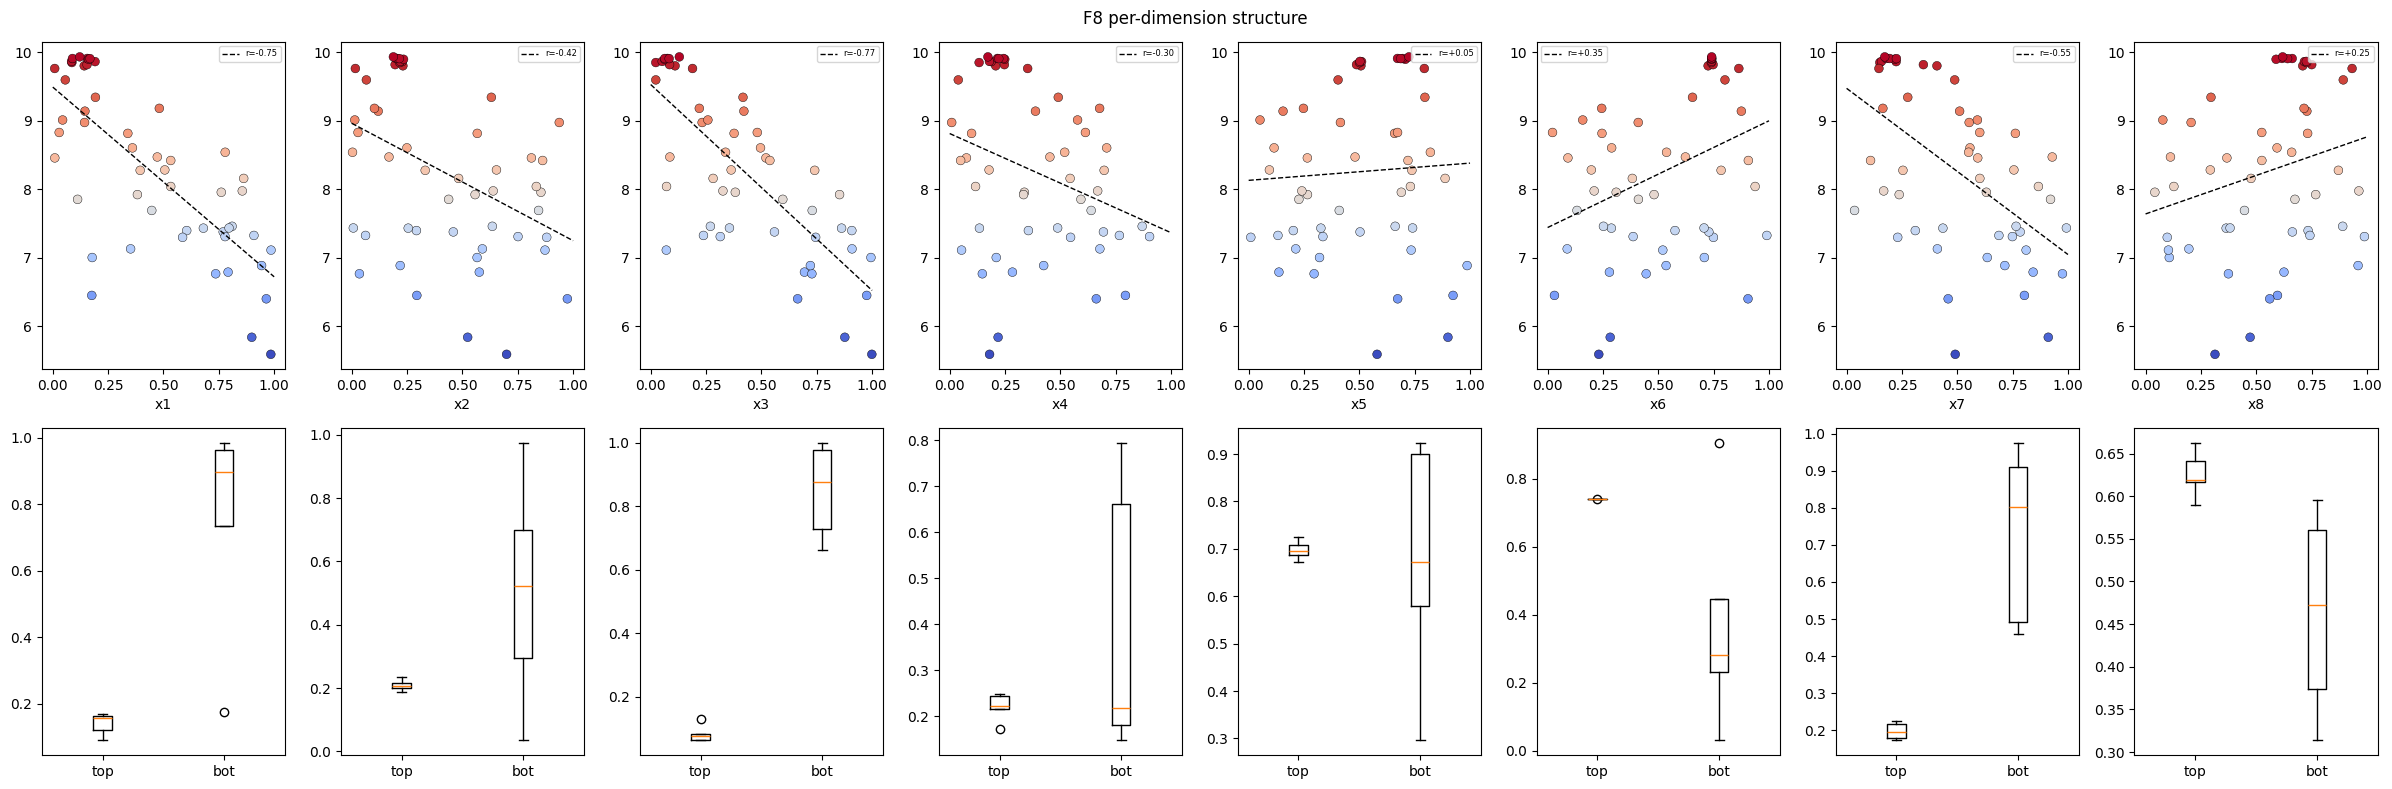

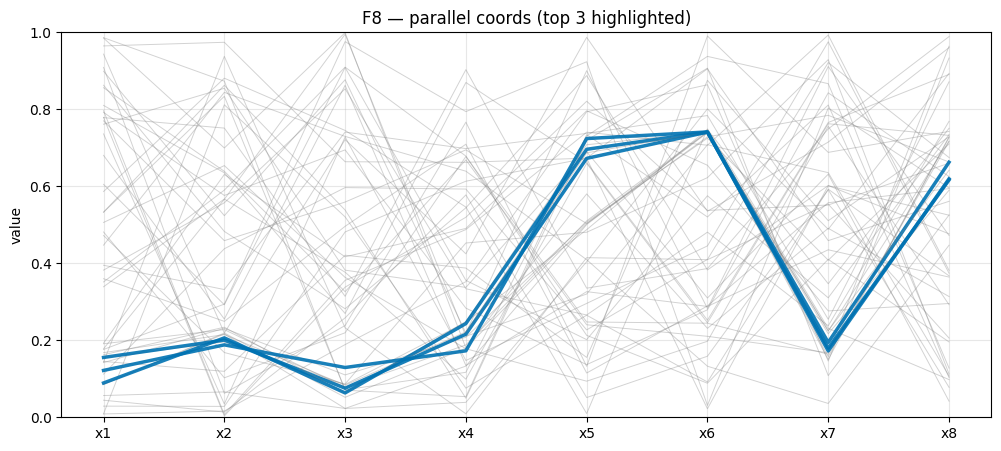

In [46]:
# Cell B — F8 per-dim scatter + boxplots + parallel coords
fig, axes = plt.subplots(2, 8, figsize=(24, 8))
for d in range(8):
    ax = axes[0, d]
    ax.scatter(X[:, d], Y, c=Y, cmap='coolwarm', s=40, edgecolor='k', linewidths=0.3)
    z = np.polyfit(X[:, d], Y, 1); xs = np.linspace(0, 1, 50)
    ax.plot(xs, np.polyval(z, xs), 'k--', lw=1, label=f'r={np.corrcoef(X[:,d],Y)[0,1]:+.2f}')
    ax.set_xlabel(f'x{d+1}'); ax.legend(fontsize=6)
    top5, bot5 = np.argsort(Y)[-5:], np.argsort(Y)[:5]
    axes[1, d].boxplot([X[top5, d], X[bot5, d]], tick_labels=['top', 'bot'])
plt.suptitle('F8 per-dimension structure')
plt.tight_layout(); plt.savefig('../plots/week_12/function_8_per_dim.png', dpi=110); plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
top3 = np.argsort(Y)[-3:]
for i, x in enumerate(X):
    if i in top3: ax.plot(range(8), x, lw=2.5, c=COLORS[0], alpha=0.9)
    else: ax.plot(range(8), x, lw=0.7, c='gray', alpha=0.35)
ax.set_xticks(range(8)); ax.set_xticklabels([f'x{i+1}' for i in range(8)])
ax.set(ylim=(0,1), ylabel='value', title='F8 — parallel coords (top 3 highlighted)'); ax.grid(alpha=0.3)
plt.savefig('../plots/week_12/function_8_parallel.png', dpi=110); plt.show()


In [47]:
# Cell C — F8 feature importance robustness
rf_all = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(X, Y).feature_importances_
rf_nobest = RandomForestRegressor(max_depth=3, n_estimators=100, random_state=0).fit(
    np.delete(X, Y.argmax(), 0), np.delete(Y, Y.argmax())).feature_importances_
lin = np.abs(LinearRegression().fit(X, Y).coef_); lin = lin / (lin.sum() + 1e-12)
corr = np.abs([np.corrcoef(X[:, i], Y)[0, 1] for i in range(X.shape[1])])
print("dim   RF(all)  RF(no best)  Linear  |corr|")
for d in range(X.shape[1]):
    flag = "  <-- INFLATED by best point" if rf_nobest[d] < 0.5 * rf_all[d] else ""
    print(f"x{d+1}    {rf_all[d]:.3f}    {rf_nobest[d]:.3f}        {lin[d]:.3f}   {corr[d]:.3f}{flag}")


dim   RF(all)  RF(no best)  Linear  |corr|
x1    0.494    0.475        0.257   0.746
x2    0.027    0.032        0.081   0.425
x3    0.340    0.354        0.365   0.769
x4    0.013    0.012        0.046   0.299
x5    0.016    0.020        0.003   0.055
x6    0.022    0.024        0.017   0.355
x7    0.079    0.074        0.208   0.555
x8    0.009    0.009        0.023   0.247


In [48]:
# Cell D — F8 model grid: standard + ceiling-warped GPs + NN
from sklearn.gaussian_process.kernels import ConstantKernel
import nn_models as nm
cv = LeaveOneOut()
def fit_grid(name, est, grid):
    gs = GridSearchCV(est, grid, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=1).fit(X, Y)
    return name, -gs.best_score_, gs.best_estimator_
results = []
results.append(fit_grid('Ridge', Ridge(), {'alpha':[0.01,0.1,1,10,100]}))
results.append(fit_grid('KNN', KNeighborsRegressor(), {'n_neighbors':[2,3,5,7],'weights':['uniform','distance']}))
results.append(fit_grid('RF', RandomForestRegressor(random_state=0), {'max_depth':[2,3,5,None],'n_estimators':[50,100,200]}))
results.append(fit_grid('SVR', SVR(kernel='rbf'), {'C':[0.1,1,10,100],'gamma':['scale','auto']}))
results.append(fit_grid('GB', GradientBoostingRegressor(random_state=0), {'max_depth':[2,3,5],'n_estimators':[50,100,200],'learning_rate':[0.01,0.1,0.3]}))
fits_f8 = {}
for name, kern, warped in [('GP-M25-iso-raw', ConstantKernel()*Matern(0.3,nu=2.5), False),
                           ('GP-RBF-iso-raw', ConstantKernel()*RBF(0.3), False),
                           ('GP-M15-ARD-warp', ConstantKernel()*Matern([0.3]*8,nu=1.5), True),
                           ('GP-M25-ARD-warp', ConstantKernel()*Matern([0.3]*8,nu=2.5), True),
                           ('GP-RBF-ARD-warp', ConstantKernel()*RBF([0.3]*8), True)]:
    target = Z if warped else Y
    errs = []
    for i in range(len(X)):
        m = np.ones(len(X), bool); m[i] = False
        gp_i = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-10, n_restarts_optimizer=2, random_state=0).fit(X[m], target[m])
        p = gp_i.predict(X[i][None])[0]
        errs.append(Y[i] - (C_CEIL - np.exp(p) if warped else p))
    rmse = float(np.sqrt(np.mean(np.array(errs)**2)))
    gp_full = GaussianProcessRegressor(kernel=kern, normalize_y=True, alpha=1e-10, n_restarts_optimizer=3, random_state=0).fit(X, target)
    fits_f8[name] = (gp_full, warped)
    results.append((name, rmse, gp_full))
nn_loaded, nn_meta = nm.load_nn(N, models_dir='../models/week_12')
results.append(('NN', nn_meta['cv_rmse'], nm.NNRegressor(nn_loaded, nn_meta)))

beats_models = {}
print(f"{'Model':>17} {'LOO RMSE':>9}  vs baseline={baseline:.4f}")
for name, rmse, est in results:
    flag = '✓' if rmse < baseline else '✗'
    if rmse < baseline: beats_models[name] = (est, rmse)
    print(f"  {name:>16} {rmse:>9.4f}  {flag} ({(1-rmse/baseline)*100:+.1f}%)")


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 12 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 13 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/_gpr.py:670: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

...

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 7 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a

/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


            Model  LOO RMSE  vs baseline=1.1900
             Ridge    0.2799  ✓ (+76.5%)
               KNN    0.4082  ✓ (+65.7%)
                RF    0.3398  ✓ (+71.4%)
               SVR    0.1495  ✓ (+87.4%)
                GB    0.2805  ✓ (+76.4%)
    GP-M25-iso-raw    0.1155  ✓ (+90.3%)
    GP-RBF-iso-raw    0.1320  ✓ (+88.9%)
   GP-M15-ARD-warp    0.1305  ✓ (+89.0%)
   GP-M25-ARD-warp    0.1876  ✓ (+84.2%)
   GP-RBF-ARD-warp    0.3238  ✓ (+72.8%)
                NN    0.4379  ✓ (+63.2%)


/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/Martin/Desktop/capstone_project_AI_ML/.venv/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 5 of parameter k2__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [49]:
# Cell E — F8 refit 4-model consensus (raw + ceiling-warped), x6 anchored, recentered
def predict_y_f8(name, c):
    gp, warped = fits_f8[name]
    p = gp.predict(c)
    return C_CEIL - np.exp(p) if warped else p

best8 = X[Y.argmax()]; ybest8 = float(Y.max())
x6_anchor = X[np.argsort(Y)[-4:], 5].mean()
rng = np.random.default_rng(0)
loc = best8 + rng.normal(0, 0.04, size=(300_000, 8))
loc[:, 5] = x6_anchor + rng.normal(0, 0.002, size=len(loc))
loc = np.clip(loc[np.linalg.norm(loc - best8, axis=1) <= 0.10], 0.012, 0.98)
print(f"{len(loc)} candidates within 0.10 of the W11 best, x6 anchored at {x6_anchor:.4f}")
use8 = ['GP-M25-iso-raw', 'GP-M15-ARD-warp', 'GP-M25-ARD-warp', 'GP-RBF-ARD-warp']
ams = []
for n_ in use8:
    m = predict_y_f8(n_, loc)
    i = int(m.argmax())
    ams.append(loc[i])
    print(f"  {n_:>16} local argmax: ({', '.join(f'{v:.3f}' for v in loc[i])})  mu={m[i]:.4f}")
ams = np.array(ams)
print(f"\nPer-dim spread: {np.round(ams.max(0)-ams.min(0), 3)}")
consensus8 = ams.mean(axis=0)
print(f"4-model consensus (x6 anchored): ({', '.join(f'{v:.6f}' for v in consensus8)})")
print(f"Step from W11 best: {np.round(consensus8-best8, 3)}, |Δ|={np.linalg.norm(consensus8-best8):.4f}")
print(f"\nPredictions at consensus (banked {ybest8:.4f}):")
for n_ in use8:
    print(f"  {n_}: {float(predict_y_f8(n_, consensus8[None])[0]):.4f}")
print("\n-> ALL FOUR predict a new best. x5-up continues for the THIRD time (0.50->0.67 won W6,")
print("   0.687->0.724 won W11, now ->0.80). Same step scale as the W11 winner (|Δ|~0.08).")


146734 candidates within 0.10 of the W11 best, x6 anchored at 0.7409
    GP-M25-iso-raw local argmax: (0.087, 0.155, 0.136, 0.146, 0.769, 0.737, 0.185, 0.670)  mu=9.9450
   GP-M15-ARD-warp local argmax: (0.128, 0.201, 0.119, 0.128, 0.804, 0.741, 0.169, 0.656)  mu=9.9519
   GP-M25-ARD-warp local argmax: (0.104, 0.190, 0.123, 0.153, 0.815, 0.740, 0.180, 0.608)  mu=9.9522
   GP-RBF-ARD-warp local argmax: (0.121, 0.182, 0.135, 0.161, 0.816, 0.738, 0.154, 0.623)  mu=9.9511

Per-dim spread: [0.041 0.046 0.017 0.032 0.047 0.004 0.031 0.062]
4-model consensus (x6 anchored): (0.110033, 0.182329, 0.128271, 0.147077, 0.800957, 0.738785, 0.171960, 0.639266)
Step from W11 best: [-0.012 -0.006 -0.001 -0.026  0.077 -0.002 -0.     0.02 ], |Δ|=0.0846

Predictions at consensus (banked 9.9345):
  GP-M25-iso-raw: 9.9398
  GP-M15-ARD-warp: 9.9477
  GP-M25-ARD-warp: 9.9491
  GP-RBF-ARD-warp: 9.9479

-> ALL FOUR predict a new best. x5-up continues for the THIRD time (0.50->0.67 won W6,
   0.687->0.724 won W1

### F8 — Decision (the W11 winner recentered; x5-up rides again)

**Query: `next_query_8 = consensus8` → ≈(0.110, 0.182, 0.128, 0.147, 0.801, 0.739, 0.172, 0.639) — refit 4-model consensus (1 raw + 3 ceiling-warped GPs), x6 anchored, |Δ|≈0.085.**

Method: identical machinery to W11 — it produced a new best (9.9345), so it repeats recentered.

The structure of the win is unusually legible for an 8D function: x5-up has now paid twice (0.50→0.67 created the W6 best; 0.687→0.724 created the W11 best), and the refit models unanimously ask for a third helping (→0.80). The x6=0.741 anchor keeps its perfect record (present in every top-4 point ever) and stays pinned against the models' weakest-consensus dim. The ceiling structure (ln(10.5−Y) diag-quadratic R² ≈ 0.98) holds with the new point, so the warped family remains 3 of the 4 voters. All four predict a new best (9.94-9.95).

Risk: the plateau's record — W10's 0.06-step lost 0.002, W8's 0.47 TuRBO bet lost only 0.15 — bounds a miss at ≈ -0.01 for this 0.085 step.

Branch (Step 5):
- [x] 5 per-dim hybrid evolved into the 4-model consensus + anchored x6 (the W10→W11→W12 lineage)

Per-dimension justification:
- x1-x4, x7 — 4-model consensus (x4 -0.026 the next-largest move)
- x5 ≈ 0.801 — consensus (+0.077; the thrice-validated climb direction)
- x6 = 0.739 — hard data anchor (every top-4 point)
- x8 ≈ 0.639 — consensus (+0.02)

W13 contingency (see suggestions_for_week_13.md):
- Y > 9.9345: x5-up pays a third time. Refit; if x5 wants 0.85+, follow — the data anchor band keeps widening.
- Y ∈ [9.90, 9.9345]: plateau edge. Micro-step around the running best, x5 back toward 0.75.
- Y < 9.88: x5=0.80 overshot the ridge. Return toward the W11 best with x5 ≈ 0.75 (split the difference).


In [50]:
# Cell I — next_query_8 assignment
next_query_8 = consensus8.copy()
print(f"F8 query: " + ", ".join(f"{v:.6f}" for v in next_query_8))
print(f"  Method: refit 4-model ceiling-warp consensus, x6 anchored, x5-up third ride")


F8 query: 0.110033, 0.182329, 0.128271, 0.147077, 0.800957, 0.738785, 0.171960, 0.639266
  Method: refit 4-model ceiling-warp consensus, x6 anchored, x5-up third ride


## Summary — Week 12 Queries

In [51]:
# === FINAL: All decided queries for F1-F8 ===
queries = {n: eval(f'next_query_{n}') for n in range(1, 9)}

print(f"Week 12 — All queries for submission:")
print("=" * 60)
for fn, q in queries.items():
    if q is not None:
        formatted = '-'.join(f'{v:.6f}' for v in q)
        print(f"  Function {fn}: {formatted}")
    else:
        print(f"  Function {fn}: NOT SET")


Week 12 — All queries for submission:
  Function 1: 0.585743-0.601770
  Function 2: 0.696090-0.946316
  Function 3: 0.519698-0.613187-0.483009
  Function 4: 0.360226-0.406461-0.420921-0.408996
  Function 5: 0.999645-0.999695-0.999678-0.999506
  Function 6: 0.423088-0.375316-0.538300-0.736429-0.054239
  Function 7: 0.134884-0.270759-0.401943-0.210085-0.295117-0.774752
  Function 8: 0.110033-0.182329-0.128271-0.147077-0.800957-0.738785-0.171960-0.639266
